## **Analytics | Loss Reporting Inference**

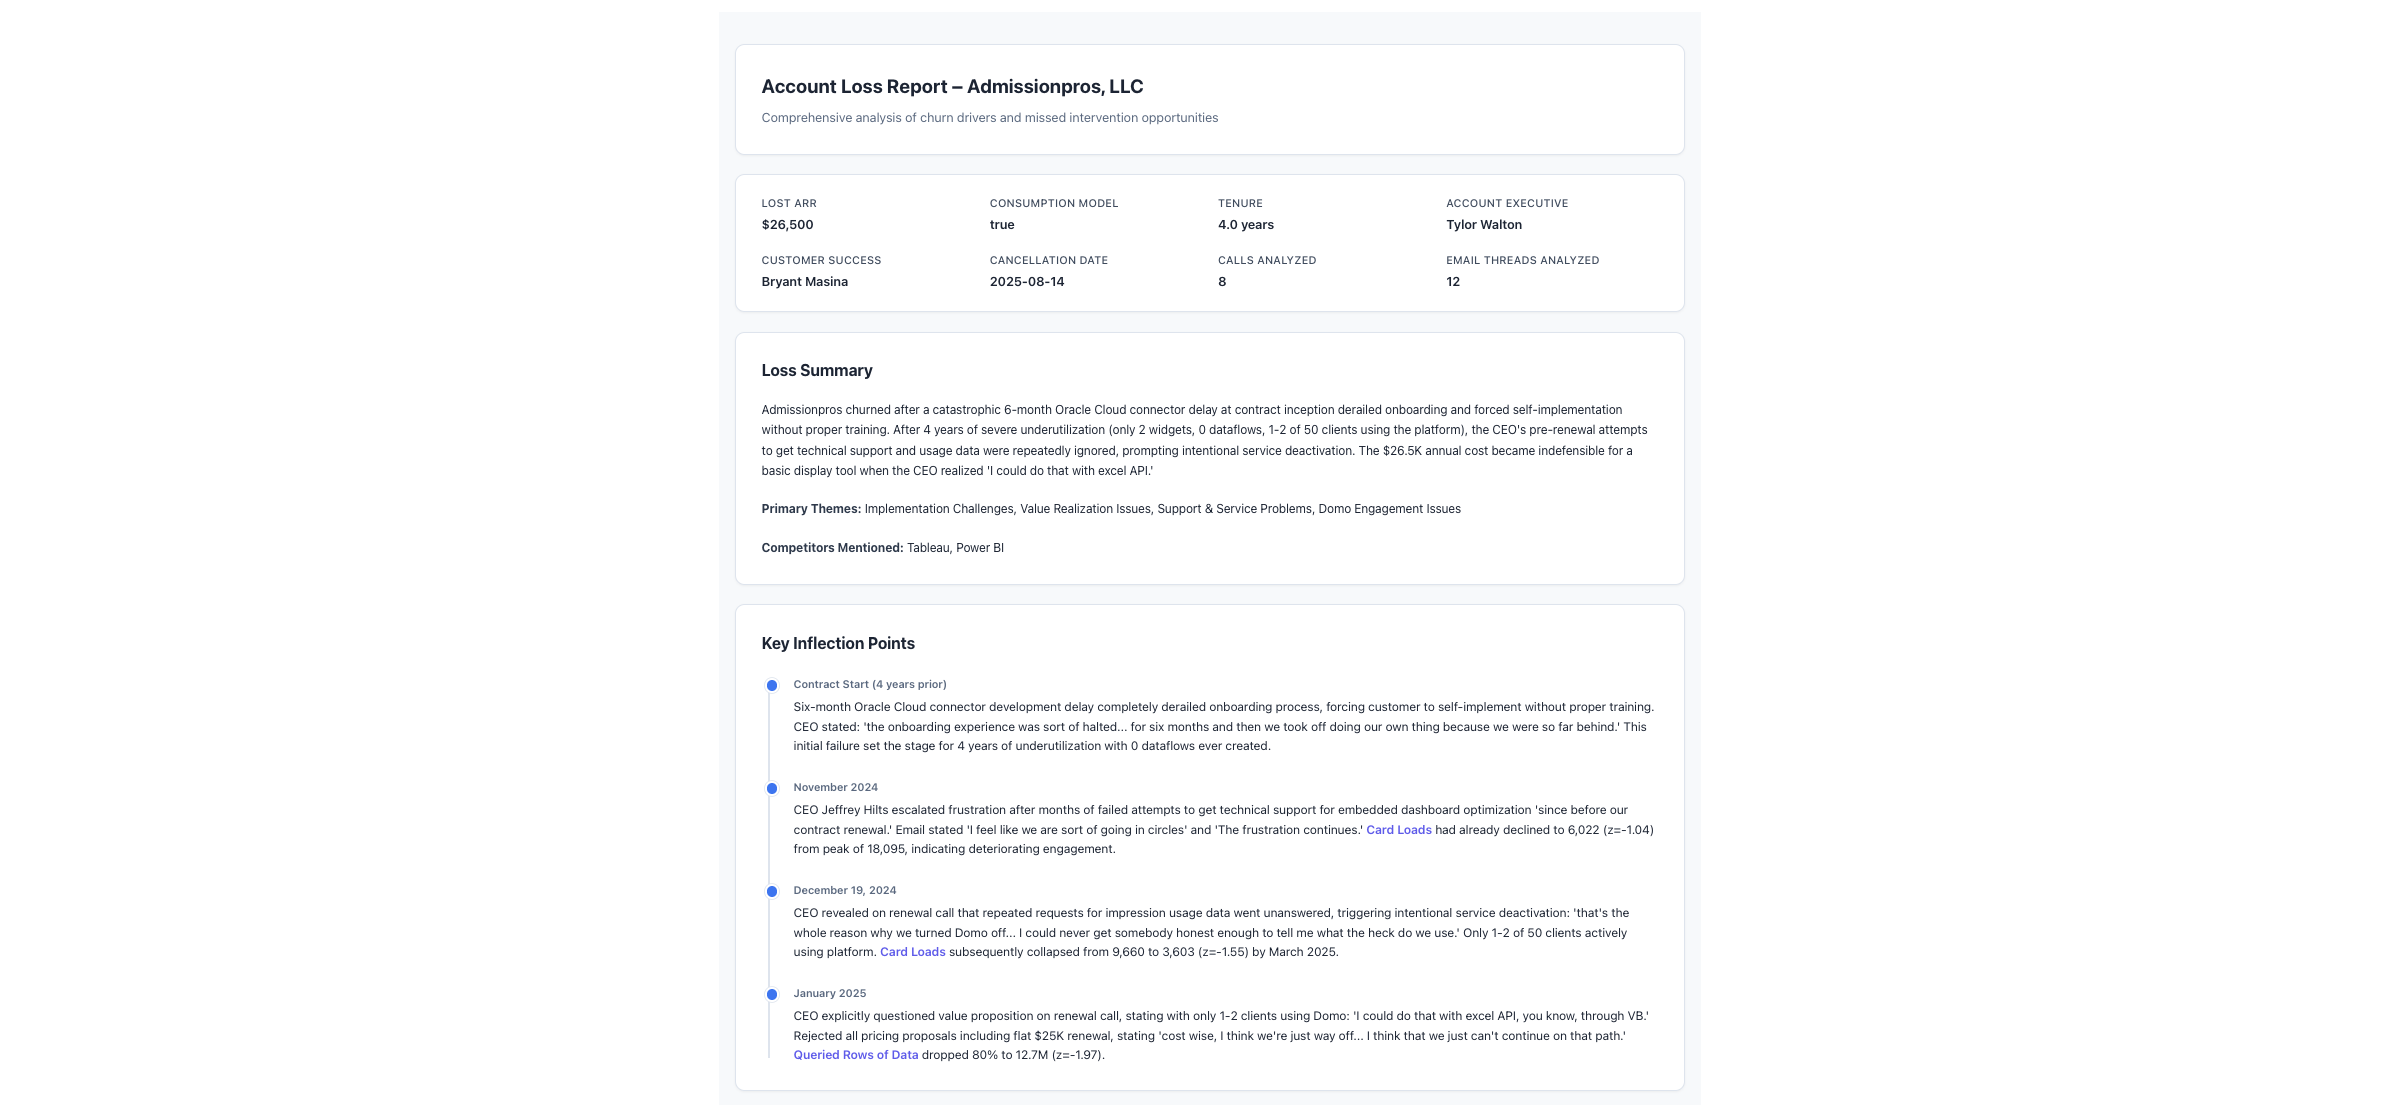

This notebook runs at the end of the quarter with the goal of understanding why each customer who churned, churned and recurring themes across accounts.

For each quarterly cohort of churned accounts, we simply want:
1. **Account Level Reports:**
    - Account Context (Lost ARR, Tenure, AE/CSM, etc.)
    - Loss Summary, Primary Themes, Competitors Mentioned
    - Key Inflection Points
    - Loss Narrative
    - Missed Signals & Intervention Opportunities
2. **Cohort Level Report:** (automate some of this, rest should be manual)
    - Context
    - Loss Theme Distribution by Accounts and ARR
    - Cohort Deep Dive
    
    
---

**Key Changes from Prev:**
1. New model (Sonnet 4 and Sonnet 4.5)
2. New architecture via SDK. Reduces (llm.prompt, llm.parallel)
3. Adding Emails + Rich sender/receiver info
4. More refined Quant metrics
5. Richer Account Context and Metadata (Context Card)


---
### **Imports and SDK Configuration**

In [1]:
import sys
import json
import time
import re
import logging
import pandas as pd
from dateutil.relativedelta import relativedelta

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

sys.path.append('../domo-automation-sdk')
from domo_sdk import *

DEV_TOKEN = "DDCI87b0c3945c4936e01e8b1636bbd8d2c6a69a7f5d331228c5"
CLIENT_ID = "4b7f6062-f87f-43e1-9d70-dac7494ad3fd"
CLIENT_SECRET = "7889480d38fa4f85f3cce2b729c44619e6767c269d361f4d3e13aa5b2709cb56"

auth(DEV_TOKEN, CLIENT_ID, CLIENT_SECRET)

A newer version of domojupyter is available. Update domojupyter with the following command:

	conda install -c https://domo-conda-prod.s3.amazonaws.com/domo domojupyter=1.1.42
Authentication successful


---
### **Stage 1a: Data**

Here, we load all the data for the relevant accounts that churned in the cohort. Then we prepare a simple function to prepare a "context card" with all the account's relevant information for each llm call.

In [2]:
query = f"""SELECT * FROM table WHERE `Cancelled Date FQ` = 'FY26 Q4' """
qualitative = data.query('d036b19d-18da-4aaf-88e1-eaeec10a4041', query)
quantitative = data.query('6b353b4e-245c-423c-aca8-9db7241bef2f', query)
context = data.query('5c06c1f8-497d-4d31-a71a-1e8aa3dcbd80', query)

print(len(qualitative), len(quantitative), len(context))

call_counts = qualitative[qualitative['Qualitative Index Type'] == 'Call'].groupby('Account Name').size()
email_counts = qualitative[qualitative['Qualitative Index Type'] == 'Email'].groupby('Account Name').size()

accounts_with_calls = call_counts[call_counts > 5].index
accounts_with_emails = email_counts[email_counts > 10].index
context_accounts = context['Account Name'].unique()

valid_accounts = accounts_with_calls.intersection(accounts_with_emails).intersection(context_accounts)

qualitative = qualitative[qualitative['Account Name'].isin(valid_accounts)]
quantitative = quantitative[quantitative['Account Name'].isin(valid_accounts)]
context = context[context['Account Name'].isin(valid_accounts)]

3246 2963 1251


## **Stage1b: Context Card**


In [7]:
def create_context_card(row):    
    card = f"""

**Account Details:**
- Account Name: {row['Account Name']}
- Industry: {row['Industry (Domo)']}
- Sales Vertical: {row['Customer Sales vertical']}
- Account Type: {row['Account Type']}

**Contract Context:**
- ARR Pre-Cancellation: ${row['ARR Pre Cancellation']}
- Consumption Model: {row['Account Consumption Model Customer']}

**Relationship Details:**
- Customer Tenure: {row['Customer Tenure (Years)']} years
- Account Executive: {row['AE']}
- Customer Success Manager: {row['CSM']}
- Cancellation Date: {row['Cancelled Date']}
- Cancellation Quarter: {row['Cancelled Date FQ']}

**Company Profile:**
- Customer Employees: {row['Customer Employees']}
- Customer Revenue: ${row['Customer Revenue']:,.0f}

""".strip()
    
    return card

context_cards = context.groupby('Account Name').first().reset_index()
context_cards['context_card'] = context_cards.apply(create_context_card, axis=1)
context_cards = context_cards[['Account Name', 'context_card']]

---

### **Stage 1: Emails**

Here, we build a pipeline that groups the email/set of emails in a thread, cleans/parses, and contextualizes them for LLM inference.

To Fix: 
- To and From not getting tagged correctly -> Heymans dataset does not include cancelled . . .
    - Reverting back to old version that was simple and contained the cancelled ones

In [9]:
EMAIL_CLEANING_PROMPT = """
# TASK
Extract only the relevant email content, removing all formatting artifacts, signatures, headers, and forwarding chains.

# INPUT
{email_content}

# INSTRUCTIONS
1. Remove email headers (From:, To:, Date:, Subject: lines that appear in body)
2. Remove email signatures and contact information
3. Remove forwarding artifacts (ZjQcmQRYFpfptBannerStart, "Beware: external email", etc.)
4. Remove HTML artifacts (&lt;, &gt;, mailto links)
5. Remove duplicate content from reply chains
6. Keep only the substantive message content
7. Preserve the chronological order (newest to oldest if multiple messages in thread)

# OUTPUT FORMAT
Return a JSON object with:
{{
  "date": "original email date",
  "from": "sender name and role",
  "to": "recipient name(s) and role(s)",
  "direction": "Inbound or Outbound",
  "subject": "email subject",
  "clean_body": "cleaned message content only, preserving key context and numbers"
}}

# QUALITY STANDARDS
- Preserve all numbers, dates, and specific details mentioned
- Keep conversational context that explains what's being discussed
- Remove only formatting junk, not substantive content
- If multiple messages in chain, separate with "---" between messages
- Keep direct quotes from customers intact

Return only the JSON object.
"""

STAGE1_EMAIL_PROMPT = """
# ROLE
You are an expert Email Communication Loss Signal Analyst at Domo. Your job is to identify specific client statements in email correspondence that indicated churn risk.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT
# OBJECTIVE
Extract 0-10 critical loss signals from the following email thread history. Include only signals with confidence ≥ 0.75 that genuinely indicate potential churn.

# ACCOUNT CONTEXT
- Account: {account_name}
- Account Context Card: {account_context}
- Total Emails Analyzed: {num_emails}

# EMAIL THREAD HISTORY
{all_emails}
*(end)*

# HOW TO READ THE INPUT DATA
The `{all_emails}` block is a *chronological* history of pre-processed and cleaned email bodies. Each email is clearly marked with:
- `-- Email X --`: The chronological number.
- `Date:`: The date of the email.
- `From:`: The sender's name and (often) their role.
- `To:`: The recipient's name and (often) their role.
- `Direction:`: Inbound or Outbound.
- `Subject:`: The email subject.
- The `clean_body` follows.

You *must* use this structured information (especially `From:`, `To:`, and `Date:`) to understand the timeline, who is speaking, and their role in the conversation.

# LOSS THEMES (Official Categories Only)
Map signals to these themes. **For Competitive Pressure theme: Always capture exact competitor names when mentioned.**
1. **Competitive Pressure**
2. **Budget & Cost Pressures**
3. **Consumption Model Concerns**
4. **Product Functionality Gaps**
5. **Value Realization Issues**
6. **Support & Service Problems**
7. **Implementation Challenges**
8. **Internal Changes & Strategy Shifts**
9. **Domo Engagement Issues**

## THEME DEFINITIONS & SIGNAL RECOGNITION

### **Competitive Pressure**
Customer actively evaluating, comparing, or switching to competitor solutions. Look for:
- Direct mentions of competitor names or parallel evaluations
- Comparisons of features, performance, or pricing with other vendors
- Statements about competitor advantages or superior capabilities

### **Budget & Cost Pressures**
External financial constraints, company-wide cost cutting, budget freezes, or economic pressures forcing spending reductions. Look for:
- References to budget cuts, cost reduction initiatives, or financial constraints
- Statements about "need to reduce spend" or "cutting costs across the board"
- Economic pressures, layoffs, or company financial difficulties

### **Consumption Model Concerns**
Issues specifically with Domo's usage-based pricing structure, credit system, or variable cost model. Look for:
- Frustration with unpredictable monthly costs or credit consumption
- Difficulty forecasting or budgeting for variable usage-based pricing
- Desire for fixed, predictable pricing instead of consumption-based

### **Product Functionality Gaps**
Missing features, performance issues, or technical limitations preventing customer success. Look for:
- Statements about missing capabilities needed for business requirements
- Performance complaints about speed, reliability, or system responsiveness
- Technical limitations blocking critical workflows or processes

### **Value Realization Issues**
Failure to achieve expected business outcomes, ROI, or promised benefits from Domo. Look for:
- Gaps between promised and delivered value or performance metrics
- Lack of user adoption or engagement with the platform
- Questioning of ROI or business case for continued investment

### **Support & Service Problems**
Issues with customer support quality, response times, or problem resolution effectiveness. Look for:
- Complaints about slow support response times or ticket resolution
- Frustration with support quality or technical expertise
- Escalation of unresolved issues or repeated problems

### **Implementation Challenges**
Difficulties with onboarding, setup, configuration, or ongoing technical implementation. Look for:
- Problems with data integration, system setup, or platform configuration
- Extended implementation timelines or technical roadblocks
- User training issues or adoption difficulties

### **Internal Changes & Strategy Shifts**
Customer organizational changes, strategic pivots, or priority shifts affecting Domo usage. Look for:
- Leadership changes, reorganizations, or strategic direction shifts
- Changing business priorities or technology strategy
- Mergers, acquisitions, or major internal restructuring

### **Domo Engagement Issues**
Problems with Domo team execution, relationship management, or customer success activities. Look for:
- Poor communication, delayed responses, or lack of proactive engagement
- Loss of key customer champions without proper relationship transfer
- Inadequate questioning, discovery, or understanding of customer needs

# EMAIL-SPECIFIC ANALYSIS CONSIDERATIONS

## Pattern Recognition Across Email Threads
- **Escalation patterns**: Issues raised multiple times or escalated to higher stakeholders
- **Response time gaps**: Long delays between customer questions and Domo responses
- **Tone shifts**: Changes from positive/neutral to frustrated or formal language
- **Stakeholder involvement**: Introduction of executives, procurement, legal in thread
- **Urgency indicators**: Deadlines mentioned, repeated follow-ups, language like "urgent" or "need answer by"

## Email vs Call Signal Differences
- Emails often contain more precise numbers, dates, and requirements
- Written communication may be more formal and direct about concerns
- Email threads reveal response quality and timeliness patterns
- Customer may document issues in email that weren't mentioned in calls
- Look for disconnect between what's said in calls vs documented in emails

# SYSTEMATIC ANALYSIS PROTOCOL

## PHASE 1: THREAD CHRONOLOGY REVIEW
<analysis_instructions>
Read through emails chronologically (oldest to newest). Track:
- Evolution of issues over time
- Escalation patterns or repeated concerns
- Domo response quality and timing
- Introduction of new stakeholders or decision makers
- Changes in customer tone or urgency

Mark ALL potentially relevant statements for deeper evaluation.
</analysis_instructions>

## PHASE 2: SIGNAL IDENTIFICATION & CATEGORIZATION
<evaluation_framework>
For each marked statement, systematically evaluate:

**A. CHURN RISK ASSESSMENT (0-1.0 scale)**
- 0.9-1.0: Explicit cancellation notices, formal termination language, or final warnings
- 0.8-0.89: Strong concerns with documented business impact or executive involvement
- 0.7-0.79: Significant issues with concrete examples and measurable impact
- 0.6-0.69: Moderate concerns but not necessarily churn-driving
- Below 0.6: Minor complaints or routine operational issues

**B. EVIDENCE STRENGTH CRITERIA**
- **Explicit**: Client directly writes about the problem and severity
- **Quantified**: Specific metrics, costs, timelines, or performance data cited
- **Documented**: Issue raised in writing, often with supporting details
- **Consequential**: Clear business impact, decision criteria, or next steps stated

**C. CONTEXTUAL FACTORS**
- When in the thread timeline did this appear?
- Who wrote it and to whom? (rank, stakeholder level)
- What was the response from Domo team?
- How many times was this issue mentioned?
- What surrounding emails provide additional context?
</evaluation_framework>

## PHASE 3: CONFIDENCE SCORING & VALIDATION
<confidence_calibration>
Apply these confidence thresholds rigorously:

**0.85-1.0 (Certainly Drives Loss)**
- Formal cancellation notice or explicit non-renewal statement
- Executive-level escalation with documented decision criteria
- Hard deadlines with stated consequences for non-resolution
- Documented competitive evaluations with specific alternatives named

**0.75-0.84 (Likely Contributes to Loss)**
- Significant unmet needs documented with business impact
- Repeated issues mentioned across multiple emails without resolution
- Budget/cost concerns with specific numbers and constraints cited
- Stakeholder escalation with decision-making authority involved

**Below 0.75 (Insufficient Evidence)**
- General complaints without measurable impact
- Routine operational questions or minor issues
- Concerns that appear to be addressed or resolved in thread
- Vague dissatisfaction without actionable specifics
</confidence_calibration>

## PHASE 4: FINAL SIGNAL SELECTION
<selection_criteria>
1. **Rank all qualified signals** (≥0.75 confidence) by score
2. **Select top 0-6 signals** - quality over quantity
3. **Ensure theme diversity** when possible
4. **Verify quote accuracy** - use exact email text
5. **Capture email metadata** - sender, date, context
6. **Double-check confidence scores** against calibration criteria
</selection_criteria>

# SIGNAL OUTPUT FORMAT
For each signal identified, return a JSON object with this *exact* structure:
{{
  "type": "Loss Theme Category",
  "verbatim_quote_or_statement": "The specific, verbatim quote (1-3 sentences) from the email body that constitutes the loss signal. Do not include the sender's name or date here.",
  "email_date": "Date of the email containing this signal (from the 'Date:' line).",
  "sender_name": "Name and role of the person who wrote this (from the 'From:' line).",
  "context_and_trigger": "A 1-3 sentence summary of the *conversational* context. What email is this in reply to? What was the previous statement from Domo or the customer? What is the *immediate trigger* for this statement being made? (e.g., 'In response to the AE's email about renewal, the customer stated...')",
  "loss_implication": "A 1-2 sentence analysis of *why* this quote is a loss signal. What is the business impact on the customer? What future negative action (e.g., non-renewal, competitive review) does it imply?",
  "confidence_score": 0.75-1.0,
  "competitor_name": "If the theme is 'Competitive Pressure' AND a competitor is named, list the competitor's name. Otherwise, null."
}}


# QUOTE CAPTURE STANDARDS

## VERBATIM ACCURACY REQUIREMENTS
- Use exact text from the cleaned email body.
- Preserve numbers, dates, and specific requirements *as written*.
- Don't paraphrase - use customer's exact written language for the `verbatim_quote_or_statement`.
- The quote should be *only* the signal, not the full email.

## CONTEXT COMPLETENESS
- Your `context_and_trigger` field *must* explain the local timeline (e.g., "This was the customer's first reply after 3 follow-ups...")
- Your `loss_implication` field *must* explain the business risk.

# QUALITY VALIDATION CHECKLIST
Before finalizing your analysis:
- [ ] All signals have confidence ≥ 0.75
- [ ] Quotes are verbatim and *only* the 1-3 sentences that are the signal.
- [ ] Email dates and senders are captured directly from the `Date:` and `From:` fields.
- [ ] `context_and_trigger` explains the *immediate* conversational flow.
- [ ] `loss_implication` explains the *business risk*.
- [ ] For Competitive Pressure: `competitor_name` field is correctly populated if a name is mentioned.
- [ ] JSON format is a valid array of objects.
- [ ] Maximum 6 signals selected (quality over quantity).

# EXECUTION INSTRUCTIONS
1. Read through ALL emails chronologically first.
2. Identify escalation patterns and repeated themes.
3. Apply evaluation framework to potential signals.
4. Use confidence calibration rigorously.
5. Select highest-quality signals only.
6. For each selected signal, construct the JSON object *exactly* as defined in `SIGNAL OUTPUT FORMAT`.
7. Return only a valid JSON array of signal objects.
8. Return an empty array `[]` if no signals meet the ≥0.75 threshold.

Return only the JSON array - no additional text.
"""

EMAIL_CLEANING_SCHEMA = {
    "type": "object",
    "properties": {
        "date": {"type": "string"},
        "from": {"type": "string"},
        "to": {"type": "string"},
        "direction": {"type": "string"},
        "subject": {"type": "string"},
        "clean_body": {"type": "string"}
    },
    "required": ["date", "from", "to", "direction", "subject", "clean_body"]
}


In [13]:
def process_single_email_clean(email_data, max_retries=3):
    email_text = f"""Date: {email_data['email_date']}
From: {email_data['From Enriched']}
To: {email_data['To Enriched']}
Direction: {email_data['Direction']}
Subject: {email_data['Email Subject Clean']}
Body: {email_data['Email Body Clean']}
"""
    
    for attempt in range(max_retries):
        try:
            result = llm.prompt(
                EMAIL_CLEANING_PROMPT,
                email_content=email_text,
                response_format=EMAIL_CLEANING_SCHEMA
            )
            
            if isinstance(result, str):
                result = json.loads(result)
            
            if not isinstance(result, dict):
                return None
            return result
            
        except Exception as e:
            if attempt == max_retries - 1:
                return None
            time.sleep(2 ** attempt)

def format_all_emails(cleaned_emails):
    formatted = []
    for i, email in enumerate(cleaned_emails, 1):
        if isinstance(email, str):
            try:
                email = json.loads(email)
            except:
                continue
        
        if not isinstance(email, dict):
            continue
            
        formatted.append(f"""-- Email {i} --
Date: {email.get('date', 'Unknown')}
From: {email.get('from', 'Unknown')}
To: {email.get('to', 'Unknown')}
Direction: {email.get('direction', 'Unknown')}
Subject: {email.get('subject', 'Unknown')}

{email.get('clean_body', '')}
""")
    return "\n\n".join(formatted)

def analyze_account_emails(account_id, account_name, account_context, max_retries=3):
    account_emails = emails_clean[emails_clean['account id'] == account_id]
    
    if len(account_emails) == 0:
        return {'account_name': account_name, 'email_analysis': ''}
    
    email_records = account_emails.to_dict('records')
    
    cleaned_emails = llm.parallel(
        items=email_records,
        prompt_func=process_single_email_clean,
        max_workers=60,
        show_progress=True
    )
    
    cleaned_emails = [e for e in cleaned_emails if e is not None and isinstance(e, dict)]
    
    if not cleaned_emails:
        return {'account_name': account_name, 'email_analysis': ''}
    
    all_emails_formatted = format_all_emails(cleaned_emails)
    
    for attempt in range(max_retries):
        try:
            analysis = llm.prompt(
                STAGE1_EMAIL_PROMPT,
                account_name=account_name,
                account_context=account_context,
                num_emails=len(cleaned_emails),
                all_emails=all_emails_formatted
            )
            return {'account_name': account_name, 'email_analysis': analysis}
            
        except Exception as e:
            if attempt == max_retries - 1:
                return {'account_name': account_name, 'email_analysis': ''}
            time.sleep(2 ** attempt)

email_columns = [
    'account id',
    'Account Name',
    'Qualitative Index Date',
    'From Enriched',
    'To Enriched',
    'Email Subject Clean',
    'Email Body Clean',
    'Direction'
]

emails = qualitative[qualitative['Qualitative Index Type'] == 'Email']
emails_clean = emails[email_columns].copy()
emails_clean = emails_clean.sort_values('Qualitative Index Date')
emails_clean = emails_clean.rename(columns={'Qualitative Index Date': 'email_date'})
unique_accounts = qualitative[['account id', 'Account Name']].drop_duplicates()

all_email_results = []
for idx, account in unique_accounts.iterrows():
    try:
        current_context_card = context_cards[context_cards['Account Name'] == account['Account Name']]['context_card'].iloc[0]
        result = analyze_account_emails(account['account id'], account['Account Name'], current_context_card)
        all_email_results.append(result)
        print(f"DONE ({idx+1}/{len(unique_accounts)}): {account['Account Name']}")
    except Exception as e:
        print(f"NOT ({idx+1}/{len(unique_accounts)}): {account['Account Name']}")
        all_email_results.append({'account_name': account['Account Name'], 'email_analysis': ''})
        continue

email_stage1_df = pd.DataFrame(all_email_results)

Processing 100 items with 60 workers...
Completed 1/100 tasks
Completed 2/100 tasks
Completed 3/100 tasks
Completed 4/100 tasks
Completed 5/100 tasks
Completed 6/100 tasks
Completed 7/100 tasks
Completed 8/100 tasks
Completed 9/100 tasks
Completed 10/100 tasks
Completed 11/100 tasks
Completed 12/100 tasks
Completed 13/100 tasks
Completed 14/100 tasks
Completed 15/100 tasks
Completed 16/100 tasks
Completed 17/100 tasks
Completed 18/100 tasks
Completed 19/100 tasks
Completed 20/100 tasks
Completed 21/100 tasks
Completed 22/100 tasks
Completed 23/100 tasks
Completed 24/100 tasks
Completed 25/100 tasks
Completed 26/100 tasks
Completed 27/100 tasks
Completed 28/100 tasks
Completed 29/100 tasks
Completed 30/100 tasks
Completed 31/100 tasks
Completed 32/100 tasks
Completed 33/100 tasks
Completed 34/100 tasks
Completed 35/100 tasks
Completed 36/100 tasks
Completed 37/100 tasks
Completed 38/100 tasks
Completed 39/100 tasks
Completed 40/100 tasks
Completed 41/100 tasks
Completed 42/100 tasks
Com

### **Stage 1b: Calls**

Here, we analyze each call

In [15]:
STAGE1_PROMPT = """
# ROLE
You are an expert Sales Call Loss Signal Analyst at Domo. Your job is to identify specific client statements, and the relevant context, that indicated churn risk in a call transcript.

# OBJECTIVE
Extract 0-4 critical loss signals from the following sales call transcript. Include only signals with confidence ≥ 0.75 that genuinely indicate potential churn.

# ACCOUNT CONTEXT:
- Context Card: {context_card}
# CALL CONTEXT  
- Account: {account_name}
- Call: {call_title}
- Date: {call_date}
- Attendees: {call_attendees}
- Call Duration: {call_duration}
- Call Recap: {call_recap}

# INPUT TRANSCRIPT
{call_body}
*(end)*

# LOSS THEMES (Official Categories Only)
Map signals to these themes. **For Competitive Pressure theme: Always capture exact competitor names when mentioned.**
1. **Competitive Pressure**
2. **Budget & Cost Pressures**
3. **Consumption Model Concerns**
4. **Product Functionality Gaps**
5. **Value Realization Issues**
6. **Support & Service Problems**
7. **Implementation Challenges**
8. **Internal Changes & Strategy Shifts**
9. **Domo Engagement Issues**

## THEME DEFINITIONS & SIGNAL RECOGNITION

### **Competitive Pressure**
Customer actively evaluating, comparing, or switching to competitor solutions. Look for:
- Direct mentions of competitor names or parallel evaluations
- Comparisons of features, performance, or pricing with other vendors
- Statements about competitor advantages or superior capabilities

### **Budget & Cost Pressures**
External financial constraints, company-wide cost cutting, budget freezes, or economic pressures forcing spending reductions. Look for:
- References to budget cuts, cost reduction initiatives, or financial constraints
- Statements about "need to reduce spend" or "cutting costs across the board"
- Economic pressures, layoffs, or company financial difficulties

### **Consumption Model Concerns**
Issues specifically with Domo's usage-based pricing structure, credit system, or variable cost model. Look for:
- Frustration with unpredictable monthly costs or credit consumption
- Difficulty forecasting or budgeting for variable usage-based pricing
- Desire for fixed, predictable pricing instead of consumption-based

### **Product Functionality Gaps**
Missing features, performance issues, or technical limitations preventing customer success. Look for:
- Statements about missing capabilities needed for business requirements
- Performance complaints about speed, reliability, or system responsiveness
- Technical limitations blocking critical workflows or processes

### **Value Realization Issues**
Failure to achieve expected business outcomes, ROI, or promised benefits from Domo. Look for:
- Gaps between promised and delivered value or performance metrics
- Lack of user adoption or engagement with the platform
- Questioning of ROI or business case for continued investment

### **Support & Service Problems**
Issues with customer support quality, response times, or problem resolution effectiveness. Look for:
- Complaints about slow support response times or ticket resolution
- Frustration with support quality or technical expertise
- Escalation of unresolved issues or repeated problems

### **Implementation Challenges**
Difficulties with onboarding, setup, configuration, or ongoing technical implementation. Look for:
- Problems with data integration, system setup, or platform configuration
- Extended implementation timelines or technical roadblocks
- User training issues or adoption difficulties

### **Internal Changes & Strategy Shifts**
Customer organizational changes, strategic pivots, or priority shifts affecting Domo usage. Look for:
- Leadership changes, reorganizations, or strategic direction shifts
- Changing business priorities or technology strategy
- Mergers, acquisitions, or major internal restructuring

### **Domo Engagement Issues**
Problems with Domo team execution, relationship management, or customer success activities. Look for:
- Poor communication, delayed responses, or lack of proactive engagement
- Loss of key customer champions without proper relationship transfer
- Inadequate questioning, discovery, or understanding of customer needs

# SYSTEMATIC ANALYSIS PROTOCOL

## PHASE 1: COMPREHENSIVE TRANSCRIPT SCAN
<analysis_instructions>
Read through the entire transcript systematically. For each speaker turn, ask yourself:
- Is this statement expressing dissatisfaction, concern, or unmet needs?
- Does this reveal comparison to competitors or alternatives?
- Are there mentions of budget constraints, cost cutting, or financial pressures?
- Are there complaints about variable pricing, credits, or consumption model complexity?
- Do I detect frustration with functionality, performance, or capabilities?
- Are there timeline pressures, implementation blockers, or stakeholder resistance?
- Is there evidence of changing priorities, strategy shifts, or internal challenges?
- Are there signs of poor Domo engagement, communication, or relationship management?
- Do I see organizational changes or key stakeholder departures?

Mark ALL potentially relevant statements for deeper evaluation.
</analysis_instructions>

## PHASE 2: SIGNAL IDENTIFICATION & CATEGORIZATION
<evaluation_framework>
For each marked statement, systematically evaluate:

**A. CHURN RISK ASSESSMENT (0-1.0 scale)**
- 0.9-1.0: Explicit threats, ultimatums, or deal-breakers stated directly
- 0.8-0.89: Strong concerns with clear business impact or consequences mentioned
- 0.7-0.79: Significant issues that could reasonably drive churn decisions
- 0.6-0.69: Moderate concerns but not necessarily churn-driving
- Below 0.6: Minor complaints or easily resolvable issues

**B. EVIDENCE STRENGTH CRITERIA**
- **Explicit**: Client directly states the problem and its severity
- **Quantified**: Specific metrics, timelines, or performance gaps mentioned
- **Behavioral**: Actions taken (testing competitors, involving stakeholders)
- **Consequential**: Clear business impact or decision implications stated

**C. CONTEXTUAL FACTORS**
- What triggered this statement? (unprompted vs. asked directly)
- When in the call did this occur? (early concern vs. late revelation)
- How did our team respond? (adequate resolution vs. deflection)
- What was the client's tone and level of detail?
</evaluation_framework>

## PHASE 3: CONFIDENCE SCORING & VALIDATION
<confidence_calibration>
Apply these confidence thresholds rigorously:

**0.85-1.0 (Certainly Drives Loss)**
- Client explicitly states they will leave if issue isn't resolved
- Active competitive evaluation with specific advantages cited
- Hard deadlines with switching consequences mentioned
- Core functionality failures that block critical business processes

**0.75-0.84 (Likely Contributes to Loss)**
- Significant unmet needs affecting business operations
- Performance gaps vs. explicit requirements or expectations
- Stakeholder resistance or approval blockers with timeline pressure
- Value realization shortfalls with team questioning ROI

**Below 0.75 (Insufficient Evidence)**
- General complaints without specific business impact
- Issues that appear resolvable with available solutions
- Minor performance concerns without stated consequences
- Vague dissatisfaction without actionable details
</confidence_calibration>

## PHASE 4: FINAL SIGNAL SELECTION
<selection_criteria>
1. **Rank all qualified signals** (≥0.75 confidence) by score
2. **Select top 0-4 signals** - quality over quantity
3. **Ensure theme diversity** when possible (avoid duplicate themes unless clearly warranted)
4. **Verify quote completeness** - capture full context and complete thoughts
5. **Double-check confidence scores** against calibration criteria
</selection_criteria>

# SIGNAL EXAMPLES - LEARN FROM THESE PATTERNS AND BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT

## Example 1: Explicit Competitive Threat with Timeline (Confidence: 0.91)
{{
  "type": "Competitive Pressure",
  "verbatim_quote_or_statement": "Jennifer Walsh (VP Operations): \"Look, I need to be direct with you. We've been running Tableau in parallel for the last month, and frankly, their dashboard performance is night and day compared to what we're seeing here. Our executive team is meeting next Friday to make a final decision, and unless we see dramatic improvement in query speeds by then, we're going to have to make the switch. The board is asking tough questions about our BI investment, and I can't keep defending slow performance when we have a working alternative sitting right there.\"",
  "speaker_name": "Jennifer Walsh (VP Operations)",
  "context_and_trigger": "Unprompted disclosure during performance discussion. Client voluntarily revealed parallel competitive evaluation and upcoming executive decision meeting. Hard deadline given (next Friday) with specific performance criteria.",
  "loss_implication": "Active competitive evaluation with quantified performance advantage for competitor. Executive-level decision meeting scheduled with explicit switching threat and hard deadline. Board-level pressure mentioned.",
  "confidence_score": 0.91,
  "competitor_name": "Tableau"
}}


## Example 2: Budget & Cost Pressures (Confidence: 0.82)
{{
  "type": "Budget & Cost Pressures",
  "verbatim_quote_or_statement": "Marcus Rodriguez (CFO): \"I need to be transparent with you - we're implementing a 20% cost reduction across all technology spend this quarter. The board has mandated significant cuts, and unfortunately BI tools are not considered mission-critical right now. We're going to have to either dramatically reduce our Domo spend or eliminate it entirely. This isn't about Domo's performance - it's purely financial survival mode for us.\"",
  "speaker_name": "Marcus Rodriguez (CFO)",
  "context_and_trigger": "CFO-initiated conversation during quarterly review. Unprompted disclosure of company-wide cost cutting mandate from board level. Explicit mention of BI tools being non-essential.",
  "loss_implication": "Board-mandated 20% technology spend reduction with BI tools categorized as non-mission-critical. CFO explicitly states elimination as option purely for financial reasons, not performance issues.",
  "confidence_score": 0.82,
  "competitor_name": null
}}

## Example 3: Consumption Model Concerns (Confidence: 0.79)
{{
  "type": "Consumption Model Concerns",
  "verbatim_quote_or_statement": "Sarah Chen (VP Finance): \"The credit system is creating serious budgeting challenges for us. Last month we burned through 150% of our expected credits, and I can't explain to the CFO why our BI costs fluctuate so wildly. We need predictable, fixed pricing - not this variable consumption model where we never know what the bill will be. Our previous solution had flat monthly pricing that made financial planning much easier.\"",
  "speaker_name": "Sarah Chen (VP Finance)",
  "context_and_trigger": "VP Finance expressing frustration during monthly review call. Unprompted complaint about credit overconsumption and billing unpredictability. Comparison to previous solution with fixed pricing model.",
  "loss_implication": "150% credit overconsumption creating budget volatility and CFO scrutiny. Client explicitly preferring fixed pricing over consumption model for financial planning purposes. Direct comparison to previous solution's predictable pricing.",
  "confidence_score": 0.79,
  "competitor_name": null
}}

## Example 4: Domo Engagement Issues (Confidence: 0.76)
{{
  "type": "Domo Engagement Issues",
  "verbatim_quote_or_statement": "David Kim (CTO): \"I have to say, since John left our company three months ago, we haven't heard much from the Domo team. John was our main champion and understood the platform well, but now my new team is struggling and we're not getting the guidance we need. When we do reach out, the responses are pretty generic and don't address our specific use cases. It feels like we're on our own now.\"",
  "speaker_name": "David Kim (CTO)",
  "context_and_trigger": "CTO feedback during quarterly check-in call. Key champion departure three months prior with no proactive Domo engagement since. Team struggling without proper guidance and receiving inadequate support responses.",
  "loss_implication": "Loss of internal champion with no relationship transfer by Domo team. New team lacking platform expertise and receiving insufficient technical guidance. Customer feeling abandoned post-champion departure.",
  "confidence_score": 0.76,
  "competitor_name": null
}}

# QUOTE CAPTURE STANDARDS

## VERBATIM ACCURACY REQUIREMENTS
- Capture exact client words including hesitations, qualifiers, and speech patterns
- Include speaker identification for multi-person exchanges
- Preserve numerical data, timeframes, and specific requirements mentioned
- Don't paraphrase or summarize - use client's exact language

## CONTEXT COMPLETENESS CHECKLIST
- What question or topic prompted this response?
- Where in the call timeline did this occur?
- What was the immediate context or trigger?
- How did our team respond (if relevant to the signal)?
- What surrounding conversation provides additional context?

## DIALOGUE FORMATTING FOR EXCHANGES
When capturing multi-turn conversations:
```
Speaker Name (Title): "Exact quote..."
Rep/Internal Person: "Response..."
Speaker Name: "Follow-up statement..."
```

# QUALITY VALIDATION CHECKLIST
Before finalizing your analysis:
- [ ] All signals have confidence ≥ 0.75
- [ ] Quotes are verbatim and complete thoughts
- [ ] Context explains timing and triggers clearly
- [ ] Loss implications are specific and business-focused
- [ ] For Competitive Pressure: Exact competitor name captured in competitor_name field
- [ ] JSON format is valid and complete
- [ ] Maximum 4 signals selected (quality over quantity)

# EXECUTION INSTRUCTIONS
1. **Work through each phase systematically** - do not skip steps
2. **Apply the evaluation framework consistently** to all potential signals
3. **Use the confidence calibration rigorously** - be conservative with scoring
4. **Follow quote capture standards precisely** - accuracy is critical
5. **Validate your final output** against the quality checklist
6. **Return only the JSON object** - no additional text or explanations
"""

In [17]:
calls = qualitative[qualitative['Qualitative Index Type'] == 'Call']
call_columns = [
    'Account Name',
    'Call Title',
    'Call Date',
    'Call Attendees',
    'Call Duration (Min)',
    'Call Recap',
    'Call Transcript',
    'Opportunity Name',
    'ARR',
    'Customer Tenure (Years)'
]
calls_clean = calls[call_columns].copy()
calls_clean = calls_clean.rename(columns={
    'Call Date': 'call_date',
    'Customer Tenure (Years)': 'customer_tenure'
})

calls_clean = calls_clean.merge(context_cards, on='Account Name', how='left')

call_records = calls_clean.to_dict('records')

def process_single_call(call_data, max_retries=3):
    for attempt in range(max_retries):
        try:
            result = llm.prompt(
                STAGE1_PROMPT,
                account_name=call_data['Account Name'],
                call_title=call_data['Call Title'],
                call_date=call_data['call_date'],
                call_attendees=call_data['Call Attendees'],
                call_duration=call_data['Call Duration (Min)'],
                call_recap=call_data['Call Recap'],
                call_body=call_data['Call Transcript'],
                context_card=call_data['context_card']
            )
            return result
            
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"Failed to process call '{call_data['Call Title']}' for {call_data['Account Name']} after {max_retries} attempts: {e}")
                return f"Analysis failed: {str(e)}"
            time.sleep(2 ** attempt) 

call_results = llm.parallel(
    items=call_records,
    prompt_func=process_single_call,
    max_workers=20,
    show_progress=True
)

calls_clean['call_analysis'] = call_results
calls_clean['analysis_failed'] = calls_clean['call_analysis'].str.startswith('Analysis failed:', na=False)

call_stage1_df = calls_clean[['Account Name', 'call_analysis']]

Processing 517 items with 20 workers...
Completed 1/517 tasks
Completed 2/517 tasks
Completed 3/517 tasks
Completed 4/517 tasks
Completed 5/517 tasks
Completed 6/517 tasks
Completed 7/517 tasks
Completed 8/517 tasks
Completed 9/517 tasks
Completed 10/517 tasks
Completed 11/517 tasks
Completed 12/517 tasks
Completed 13/517 tasks
Completed 14/517 tasks
Completed 15/517 tasks
Completed 16/517 tasks
Completed 17/517 tasks
Completed 18/517 tasks
Completed 19/517 tasks
Completed 20/517 tasks
Completed 21/517 tasks
Completed 22/517 tasks
Completed 23/517 tasks
Completed 24/517 tasks
Completed 25/517 tasks
Completed 26/517 tasks
Completed 27/517 tasks
Completed 28/517 tasks
Completed 29/517 tasks
Completed 30/517 tasks
Completed 31/517 tasks
Completed 32/517 tasks
Completed 33/517 tasks
Completed 34/517 tasks
Completed 35/517 tasks
Completed 36/517 tasks
Completed 37/517 tasks
Completed 38/517 tasks
Completed 39/517 tasks
Completed 40/517 tasks
Completed 41/517 tasks
Completed 42/517 tasks
Com

### **Stage 1c: Metrics**

Last changes:
- Limit to < cancel date
- Each metric MoM instead of each month with all

In [18]:
def prepare_metrics_for_account(account_name):
    account_metrics = quantitative[quantitative['Account Name'] == account_name].copy()
    
    if len(account_metrics) == 0:
        return {'account_name': account_name, 'metrics_json': '{}'}
    
    # Filter to months before cancellation and sort
    account_metrics = account_metrics[account_metrics['Days to Cancel'].notna()].sort_values('Month')
    
    if len(account_metrics) == 0:
        return {'account_name': account_name, 'metrics_json': '{}'}
    
    base_metrics = [
        'Card Loads', 'Stored Rows of Data', 'Queried Rows of Data',
        'Cards Created', 'Dataflows Created', 'Datasets Created',
        'Domo Desktop Visit', 'Dataflow Run', 'Unique User Logins'
    ]
    
    # Build structure: one entry per metric with all months
    metrics_data = {}
    
    for metric in base_metrics:
        month_values = {}
        has_data = False
        
        for _, row in account_metrics.iterrows():
            # Format month as YYYY-MM
            month_str = str(row['Month'])[:7]
            
            if pd.notna(row.get(metric)):
                val = row[metric]
                zscore = row.get(f"{metric}_zscore")
                month_values[month_str] = f"{val}(z={round(zscore, 2)})" if pd.notna(zscore) else str(val)
                has_data = True
        
        # Only include metric if it has any data
        if has_data:
            metrics_data[metric] = month_values
    
    return {
        'Account Name': account_name,
        'metrics_json': json.dumps(metrics_data, indent=2)
    }

# Process all accounts
metrics_results = [
    prepare_metrics_for_account(account_name)
    for account_name in qualitative['Account Name'].drop_duplicates()
]

metrics_stage1_df = pd.DataFrame(metrics_results)

---

### **Stage 2a: Triangulation**

TO DO: 
- break out stage 2 into two steps:
    1. Just focuses on content extraction and triangulation
    2. Just focuses on creating a crispy HTML document
    
IMPACT: 
- allows more flexibility on each tasks, reduces dillution on each task, better for testing.


In [20]:
STAGE2_TRIANGULATION_PROMPT = """
# ROLE
You are an Expert Churn Forensics Analyst at Domo. Your primary objective is to analyze comprehensive account data to produce a concise, evidence-backed analysis explaining precisely *why* account **"{account_name}"** churned and the signals we (Domo) missed.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT

# CORE TASK
Synthesize the provided email analysis, call analysis, and quantitative metric data into an evidence-backed JSON report. You will first create a "reasoning_scratchpad" to build your chain of thought, then use that reasoning to generate the four core components: 1) Loss Summary, 2) Key Inflection Points, 3) Loss Narrative, and 4) Missed Signals.

# INPUTS
## Account Context
- Account: {account_name}
- Account Context: {context_card}
- Cancellation Date: {cancellation_date}

## Email Analysis
{email_analysis}

## Call Analysis
{call_analysis}

## Metrics Time Series
{metrics_json}

### INPUT INTERPRETATION GUIDE

**Email Analysis Structure:**
The email analysis contains identified loss signals from email correspondence with the following fields:
- **type**: Loss theme category
- **verbatim_quote_or_statement**: Exact text from emails
- **email_date**: When the email was sent
- **sender_name**: Who wrote the email (with role)
- **context_and_trigger**: Thread history and what prompted the email
- **loss_implication**: Why this indicates churn risk
- **confidence_score**: 0.75-1.0 confidence level
- **competitor_name**: Competitor mentioned (if applicable)

**Call Analysis Structure:**
The call analysis contains identified loss signals from call transcripts with the following fields:
- **type**: Loss theme category
- **verbatim_quote_or_statement**: Exact quotes from calls
- **speaker_name**: Who said it (with role)
- **context_and_trigger**: What prompted the statement in the call
- **loss_implication**: Why this indicates churn risk
- **confidence_score**: 0.75-1.0 confidence level
- **competitor_name**: Competitor mentioned (if applicable)

**Metrics Structure:**
Each month's metrics include:
- **month**: Calendar month (e.g., "2024-03")
- **days_to_cancel**: Days until cancellation (lower = closer to churn)
- **Metric values**: Formatted as "value (z=zscore)" where z-score indicates deviation from account's baseline

**Key Interpretation Patterns:**
- **days_to_cancel**: Use to identify timeline proximity to churn (e.g., 90 days = 3 months before cancellation)
- **Z-scores**: Values with z < -1.5 indicate significant declines, z > 1.5 indicate significant increases
- **Triangulation**: Match email/call dates with corresponding days_to_cancel periods for signal-metric correlation
- **Leading indicators**: Metrics showing decline before explicit customer complaints
- **Trend analysis**: Compare metrics across months to identify acceleration of decline

# ANALYSIS PROTOCOL
Execute these steps in sequence. **Step 1 is the most critical to perform first.**

## Step 1: Pre-Analysis Reasoning & Triangulation (Chain of Thought)
<chain_of_thought>
- **Scan All Evidence:** First, quickly review all inputs (emails, calls, metrics) to get a holistic view.
- **Identify Key Signals:** In your scratchpad, list the 3-5 most critical qualitative signals (quotes from calls/emails) that seem to be the "smoking guns." Note their date and speaker.
- **Identify Key Inflections:** In your scratchpad, list the 2-4 most significant metric inflection points (e.g., "Unique User Logins z=-2.5 at 120 days_to_cancel").
- **Form Triangulations:** Explicitly connect the signals and metrics. For example: "The customer's email about 'implementation challenges' on Jan 15 (110 days_to_cancel) lines up perfectly with the 'Cards Created' metric falling to 0 (z=-3.1) in that same period."
- **Hypothesize Root Cause:** Based on these triangulated points, formulate a 1-2 sentence root cause hypothesis. This hypothesis will form the basis of your `core_reason`.
- **Populate `reasoning_scratchpad`:** You will place this analysis in the `reasoning_scratchpad` object in the final JSON output.
</chain_of_thought>

## Step 2: Evidence Validation & Curation
<evidence_validation>
- **Review:** Examine all loss signals from both email and call analyses.
- **Quality Filter:** Prioritize signals that best answer "why did this account churn?"
- **Source Integration:** Consider both email (written, more formal) and call (spoken, more candid) sources equally.
- **Quote Enhancement:** Optimize quotes for readability while preserving intent:
  - Remove excessive filler words using ellipses (...)
  - Preserve speaker's original intent and tone
  - Maintain quantified statements and specific details exactly as stated
- **Chronological Sequencing:** Order all signals by date to establish timeline.
</evidence_validation>

## Step 3: Deep Metric Correlation & Pattern Analysis
<metric_analysis>
- **Signal-Metric Alignment:** For each email/call signal, examine metrics within ±90 days using days_to_cancel as temporal anchor.
- **Timeline Triangulation:** Match customer complaint timing with metric decline patterns using days_to_cancel values.
- **Z-Score Analysis:** Identify metrics with significant z-scores (< -1.5 or > 1.5) that correlate with complaints.
- **Causal Connection Mapping:** Identify explicit cause-and-effect relationships between customer statements and metric changes (as practiced in Step 1).
- **Leading vs. Lagging Indicators:** Distinguish between metrics that declined before customer complaints (leading) vs. those that declined after complaints were raised (lagging).
- **Pattern Recognition:** Identify metric behaviors that support the narrative timeline:
  - **Early warning signals** (>180 days to cancel): Subtle declines that preceded explicit complaints
  - **Escalation period** (90-180 days): Accelerating declines during customer concern escalation
  - **Point of no return** (<90 days): Dramatic drops in final months before cancellation
</metric_analysis>

## Step 4: Theme Identification & Competitive Intelligence
<theme_mapping>
Map signals to official loss themes:
- **Competitive Pressure**
- **Budget & Cost Pressures**
- **Consumption Model Concerns**
- **Product Functionality Gaps**
- **Value Realization Issues**
- **Support & Service Problems**
- **Implementation Challenges**
- **Internal Changes & Strategy Shifts**
- **Domo Engagement Issues**

**Competitor Intelligence:**
- Extract all competitor mentions from both email and call signals.
- For each competitor, note: context of mention, speaker authority level, and competitive advantage cited.
- Document whether competitors were actively evaluated or just mentioned.
</theme_mapping>

## Step 5: Root Cause Analysis & Narrative Synthesis
<narrative_construction>
- **Refine Hypothesis:** Take your `root_cause_hypothesis` from Step 1 and confirm or refine it using the full evidence base.
- **Primary Theme Identification:** Determine the root cause theme(s) based on evidence frequency and severity.
- **Timeline-Driven Causal Chain:** Trace how initial concerns evolved into deal-breaking issues using days_to_cancel:
  - **Early Period** (>270 days): Baseline performance and early warning signs
  - **Concern Emergence** (180-270 days): First explicit customer concerns and metric correlations
  - **Escalation Phase** (90-180 days): Issue amplification and metric deterioration acceleration
  - **Point of No Return** (<90 days): Final attempts and irreversible churn decision
- **Evidence Weaving:** Integrate qualitative signals (emails + calls) with quantitative proof points into a chronological story. **This is where you write the full `timeline_analysis` paragraph(s).**
- **Signal-Metric Fusion:** Connect every major customer statement with corresponding metric changes.
</narrative_construction>

## Step 6: Extract Key Inflection Points
<timeline_extraction>
- **Review Narrative:** Read through the `timeline_analysis` you just wrote in Step 5.
- **Identify 3-4 Milestones:** Select the 3-4 most critical "milestone" events that best summarize the path to churn (e.g., the first warning, the competitive evaluation, the "point of no return").
- **Format for Timeline:** For each event, create an object with:
  - `date`: The date of the event (e.g., "March 2025").
  - `description`: A 1-2 sentence summary of the event, integrating any key metric impact (e.g., "CTO David initiated technology cost review following second layoff round as Desktop Visits dropped -23%.").
- **Populate `key_inflection_points`:** Add these objects in chronological order to the `key_inflection_points` array.
</timeline_extraction>

## Step 7: Missed Signal & Intervention Analysis
<intervention_analysis>
Identify EXACTLY 3 pivotal moments where proactive intervention could have prevented churn.
- **Signal Selection Criteria:**
- **High Impact:** Choose signals that, if addressed, would have materially changed the outcome.
- **Clear Timeline:** Select signals spread across the customer journey (early, middle, late stage).
- **Actionable:** Each signal must have a concrete, executable intervention.
- **Evidence-Based:** Every signal must tie directly to quotes and/or metrics from the data.
- **For each missed signal:**
1. **The Warning:** What the customer said/did that we missed (with quote).
2. **The Metric Evidence:** How this manifested in quantitative data.
3. **The Intervention:** Specific action with WHO, WHAT, WHEN, WHY.
</intervention_analysis>

# OUTPUT FORMAT

Return a JSON object with this exact structure. **Populate `reasoning_scratchpad` FIRST.**
{{
  "reasoning_scratchpad": {{
    "key_qualitative_signals": [
      {{
        "date": "YYYY-MM-DD",
        "source": "email/call",
        "signal": "The verbatim quote or summary of the key signal.",
        "speaker": "Speaker Name (Role)"
      }}
    ],
    "key_metric_inflections": [
      {{
        "month": "YYYY-MM",
        "metric": "Metric Name",
        "value": "Value (z=ZScore)",
        "days_to_cancel": 123
      }}
    ],
    "triangulation_notes": [
      "Initial hypothesis: The 40% drop in 'Unique User Logins' (z=-2.1) 90 days before cancel directly followed the CSM's email on 2024-01-15 about 'implementation challenges'. This suggests a failed adoption.",
      "A second key triangulation: The VP of Finance mentioned 'budget cuts' in a call, which happened 30 days *after* usage metrics had already cratered, suggesting the budget issue was a lagging excuse, not the leading cause."
    ],
    "root_cause_hypothesis": "The primary driver appears to be a failed implementation and lack of value realization, leading to a complete drop in user adoption. The subsequent budget pressure was likely an accelerator for a decision that was already made."
  }},
  "loss_summary": {{
    "primary_themes": ["Theme 1", "Theme 2 (if applicable)"],
    "core_reason": "2-3 sentence summary derived from your hypothesis. **Example:** 'LendingPoint churned due to severe financial distress. Despite acknowledging Domo's superiority, the $230K cost differential with <span class='competitor'>Tableau</span> ($300K vs $70K) became unsustainable during their \"keep the lights on mode\" operations.'",
    "competitors_mentioned": ["Competitor 1", "Competitor 2"]
  }},
  "key_inflection_points": [
    {{
      "date": "YYYY-MM-DD or Month YYYY",
      "description": "A 1-2 sentence summary of the critical event, integrating any key metric (e.g., 'CTO David initiated cost review as Desktop Visits dropped -23%.')"
    }},
    {{
      "date": "YYYY-MM-DD or Month YYYY",
      "description": "A 1-2 sentence summary of the second critical event."
    }}
  ],
  "loss_narrative": {{
    "timeline_analysis": "4 paragraphs, 3-4 sentences each, chronological story weaving emails, calls, and metrics, showing clear causal connections. **Example of a strong narrative sentence:** 'The churn trajectory began in Q1 as <span class='metric'>Monthly Active Users</span> dropped to 694 (z=-1.8) 210 days before cancellation, which directly followed a Feb 12th call where CTO David Stevens stated: \"We're scrutinizing every technology investment.\"' "
  }},
  "missed_signals": [
    {{
      "signal_number": 1,
      "date": "YYYY-MM-DD",
      "signal_description": "2-3 sentence description. **Example:** 'CS missed a budget signal when CTO David stated \"we're scrutinizing every technology investment\" following the first layoff, while <span class='metric'>Monthly Active Users</span> declined 18%.'",
      "metric_evidence": "Specific metric changes with z-scores and timeline context. **Example:** '<span class='metric'>Monthly Active Users</span> dropped from 847 to 694 (z=-1.8). <span class='metric'>Cards Created</span> fell from 156 to 98.'",
      "intervention": "Specific, actionable intervention. **Example:** 'CSM should have immediately escalated to Sales/Finance (WHO) to develop a competitive save offer (WHAT) before the <span class='competitor'>Tableau</span> evaluation was formalized (WHEN).'"
    }},
    {{
      "signal_number": 2,
      "date": "YYYY-MM-DD",
      "signal_description": "...",
      "metric_evidence": "...",
      "intervention": "..."
    }},
    {{
      "signal_number": 3,
      "date": "YYYY-MM-DD",
      "signal_description": "...",
      "metric_evidence": "...",
      "intervention": "..."
    }}
  ]
}}

# ANALYSIS STANDARDS
<analysis_guidelines>
- **Reasoning First:** All conclusions in `loss_summary` and `loss_narrative` MUST be directly supported by the findings in your `reasoning_scratchpad`.
- **Evidence-Based Causality:** Every claim must be supported by provided input data (emails, calls, metrics), preferably a triangulation.
- **Deep Triangulation:** Connect every major customer statement with corresponding metric changes.
- **Chronological Flow:** Present the loss story as it unfolded over time.
- **Specific Details:** Include exact dates, speaker names/titles, metric values with z-scores.
- **Quantitative Proof:** For every qualitative signal, find supporting or contradicting metrics.
- **Quote Integration:** Use complete, impactful quotes as needed to tell the story.
- **Metric Specificity:** Always include z-scores and days_to_cancel when citing metrics.
</analysis_guidelines>

# DATA QUALITY HANDLING
<data_handling>
- **Sparse Evidence:** If limited high-confidence signals exist, state this in the `reasoning_scratchpad` and `loss_narrative`.
- **Metric Gaps:** If metrics lack correlation to signals, acknowledge this explicitly in the `triangulation_notes`.
- **Confidence Transparency:** Weight narrative toward higher-confidence signals (≥0.85).
- **Missing Context:** Focus on available evidence without speculation.
</data_handling>

# EXECUTION INSTRUCTIONS
1. **Fill out the `reasoning_scratchpad` FIRST.** This is not optional. Build your chain of thought here before writing any other section.
2. **Derive `loss_summary`:** Your `core_reason` should be a polished version of your `root_cause_hypothesis`.
3. **Build `loss_narrative`:** Expand on the `triangulation_notes` and chronological signals to tell the full story.
4. **Extract `key_inflection_points`:** After writing the narrative, extract the 3-4 key milestones for the timeline.
5. **Identify `missed_signals`:** Select the 3 most critical, actionable moments from your evidence.
6. **Return valid JSON only** - no additional text or explanations.

Generate the JSON analysis now.
"""

In [21]:
def generate_stage2_report_with_retry(account_name, max_retries=3):

    if not STAGE2_TRIANGULATION_PROMPT:
        print(f"Error: STAGE2_TRIANGULATION_PROMPT is empty. Cannot proceed for {account_name}.")
        return {
            'account_name': account_name,
            'stage2_report': json.dumps({"error": "STAGE2_TRIANGULATION_PROMPT is not loaded."}),
            'error': "Prompt not loaded"
        }
        
    for attempt in range(max_retries):
        try:
            
            email_data = email_stage1_df[email_stage1_df['account_name'] == account_name]
            call_data = call_stage1_df[call_stage1_df['Account Name'] == account_name]
            metrics_data = metrics_stage1_df[metrics_stage1_df['Account Name'] == account_name]
            
            email_analysis = email_data['email_analysis'].iloc[0] if len(email_data) > 0 else "[]"
            call_analysis = "\n\n".join(call_data['call_analysis'].tolist()) if len(call_data) > 0 else "[]"
            metrics_json = metrics_data['metrics_json'].iloc[0] if len(metrics_data) > 0 else "{}"
            
            cancellation_date = qualitative[qualitative['Account Name'] == account_name]['Cancelled Date'].iloc[0]
            context_card = context_cards[context_cards['Account Name'] == account_name]['context_card'].iloc[0]

            # 2. Call the LLM (this is the part that benefits from parallelism)
            report_json_str = llm.prompt(
                STAGE2_TRIANGULATION_PROMPT,
                account_name=account_name,
                cancellation_date=cancellation_date,
                email_analysis=email_analysis,
                call_analysis=call_analysis,
                metrics_json=metrics_json,
                context_card=context_card
            )

            return {'account_name': account_name, 'stage2_report': report_json_str, 'error': None}
        
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {account_name}: {e}")
            if attempt == max_retries - 1:
                error_msg = f"Analysis failed after {max_retries} attempts: {str(e)}"
                return {
                    'account_name': account_name,
                    'stage2_report': json.dumps({"error": error_msg}), # Return a valid JSON string with an error key
                    'error': str(e)
                }
            time.sleep(2 ** attempt)

unique_account_names = qualitative['Account Name'].unique().tolist()
print(f"Found {len(unique_account_names)} unique accounts to triangulate...")

stage2_results_list = llm.parallel(
    items=unique_account_names,
    prompt_func=generate_stage2_report_with_retry, # Our new worker function
    max_workers=10, # Can be tuned
    show_progress=True
)

stage2_df = pd.DataFrame(stage2_results_list)


Found 34 unique accounts to triangulate...
Processing 34 items with 10 workers...
Completed 1/34 tasks
Completed 2/34 tasks
Completed 3/34 tasks
Completed 4/34 tasks
Completed 5/34 tasks
Completed 6/34 tasks
Completed 7/34 tasks
Completed 8/34 tasks
Completed 9/34 tasks
Completed 10/34 tasks
Completed 11/34 tasks
Completed 12/34 tasks
Completed 13/34 tasks
Completed 14/34 tasks
Completed 15/34 tasks
Completed 16/34 tasks
Completed 17/34 tasks
Completed 18/34 tasks
Completed 19/34 tasks
Completed 20/34 tasks
Completed 21/34 tasks
Completed 22/34 tasks
Completed 23/34 tasks
Completed 24/34 tasks
Completed 25/34 tasks
Completed 26/34 tasks
Completed 27/34 tasks
Completed 28/34 tasks
Completed 29/34 tasks
Completed 30/34 tasks
Completed 31/34 tasks
Completed 32/34 tasks
Completed 33/34 tasks
Completed 34/34 tasks
Completed in 344.7 seconds




### **Stage 2b: Individual Account HTML Reports**

Takes the output from 2a and formats it into a clean html report.

In [22]:
STAGE2B_FORMATTER_PROMPT = """
# ROLE
You are an expert HTML report generator. Your *only* task is to take the provided account metadata and the JSON analysis object and perfectly populate a final HTML report template. You must not add any new analysis, opinions, or text that isn't derived from the inputs.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT
# CORE TASK
Populate the `[[PLACEHOLDER]]` sections in the provided HTML template using the data from the `{account_metadata_json}` and `{analysis_json}` inputs.

# INPUTS
1.  **`{account_name}`**: The name of the account (e.g., "LendingPoint LLC").
2.  **`{account_metadata_json}`**: A JSON string containing the account's static information.
3.  **`{analysis_json}`**: A JSON string containing the full analysis from Stage 2a (loss summary, timeline, signals).

# INSTRUCTIONS
1.  Parse the `{account_metadata_json}` string to get the account's metadata.
2.  Parse the `{analysis_json}` string to get the `loss_summary`, `key_inflection_points`, `loss_narrative`, and `missed_signals` objects.
3.  **Fill Header:**
    * Replace `[[ACCOUNT_NAME]]` in the `<title>` and `<h1>` tags with the `{account_name}`.
4.  **Fill Info Grid:**
    * Iterate through the `{account_metadata_json}`. For each key-value pair (e.g., "Lost ARR": "$300,000"), generate an HTML block:
        ```html
        <div class='info-item'>
          <span class='info-label'>[Key]</span>
          <span class='info-value'>[Value]</span>
        </div>
        ```
    * Replace `[[INFO_GRID_HTML]]` with the complete set of these `info-item` divs.
5.  **Fill Loss Summary:**
    * Use the `loss_summary` object.
    * Place `loss_summary.core_reason` inside the first `<p>` tag.
    * Generate `<p><strong>Primary Theme:</strong> [Theme]</p>` from `loss_summary.primary_themes`.
    * Generate `<p><strong>Competitors Mentioned:</strong> [Competitors]</p>` from `loss_summary.competitors_mentioned`.
    * Replace `[[LOSS_SUMMARY_HTML]]` with this content.
6.  **Fill Key Inflection Points (Timeline):**
    * Iterate through the `key_inflection_points` array. For each item, generate an HTML block:
        ```html
        <div class='timeline-item'>
          <div class='timeline-dot'></div>
          <div class='timeline-date'>[[item.date]]</div>
          <div class='timeline-content'>
            [[item.description]]
          </div>
        </div>
        ```
    * Replace `[[TIMELINE_ITEMS_HTML]]` with the complete set of these `timeline-item` divs.
7.  **Fill Loss Narrative:**
    * Place the `loss_narrative.timeline_analysis` string directly into the `[[NARRATIVE_HTML]]` placeholder (it should be a pre-formatted string with `<p>` tags).
8.  **Fill Missed Signals:**
    * Iterate through the `missed_signals` array. For each signal, generate an HTML block:
        ```html
        <div class='missed-signal'>
          <div class='signal-header'>
            <span class='signal-date'>[[signal.date]]</span>
          </div>
          <div class='signal-content'>
            <p>[[signal.signal_description]]</p>
            <br>
            <p><strong>Metric Evidence:</strong> [[signal.metric_evidence]]</p>
          </div>
          <div class='signal-intervention'>
            <strong>Recommended Intervention:</strong>
            <p>[[signal.intervention]]</p>
          </div>
        </div>
        ```
    * Replace `[[MISSED_SIGNALS_HTML]]` with the complete set of these `missed-signal` divs.
9.  **Return ONLY the final, complete HTML document.** Do not include any other text, reasoning, or markdown.

# FULL HTML TEMPLATE
<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>Account Loss Report – [[ACCOUNT_NAME]]</title>
  <meta name='viewport' content='width=device-width,initial-scale=1'>
  <style>
    :root {{
      --bg: #f8fafc;
      --card-bg: #ffffff;
      --text: #1e293b;
      --subtext: #64748b;
      --border: #e2e8f0;
      --accent: #3b82f6;
      --metric-color: #6366f1;
      --competitor-bg: #f1f5f9;
      --timeline-dot: #3b82f6;
      --timeline-line: #e2e8f0;
      --signal-bg: #fef3c7;
      --signal-border: #f59e0b;
      --radius: 12px;
      --radius-sm: 8px;
    }}
    
    * {{ box-sizing: border-box; }}
    
    body {{
      margin: 0;
      font-family: 'Inter', -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
      background: var(--bg);
      color: var(--text);
      line-height: 1.6;
      -webkit-font-smoothing: antialiased;
      font-size: 15px;
    }}
    
    .wrapper {{
      display: flex;
      justify-content: center;
      padding: 40px 20px;
    }}
    
    .container {{
      width: 100%;
      max-width: 1200px;
    }}
    
    /* Header Section */
    .header-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .header-title {{
      font-size: 1.5rem;
      font-weight: 700;
      color: var(--text);
      margin: 0 0 8px 0;
    }}
    
    .header-subtitle {{
      color: var(--subtext);
      font-size: 1rem;
      margin: 0;
    }}
    
    /* Info Section */
    .info-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 24px 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .info-grid {{
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 20px;
    }}
    
    .info-item {{
      display: flex;
      flex-direction: column;
      gap: 4px;
    }}
    
    .info-label {{
      font-size: 0.85rem;
      color: #475569;
      font-weight: 500;
      text-transform: uppercase;
      letter-spacing: 0.03em;
    }}
    
    .info-value {{
      font-size: 1rem;
      color: var(--text);
      font-weight: 600;
    }}
    
    /* Content Sections */
    .content-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .content-section h3 {{
      margin: 0 0 20px 0;
      font-size: 1.25rem;
      font-weight: 700;
      color: var(--text);
    }}
    
    .content-section h4 {{
      margin: 24px 0 16px 0;
      font-size: 1.1rem;
      font-weight: 600;
      color: var(--text);
    }}
    
    .content-section p {{
      margin: 0 0 1.5em 0;
      color: var(--text);
      line-height: 1.7;
    }}
    
    .content-section p:last-child {{
      margin-bottom: 0;
    }}

    .content-section p strong {{
        color: #334155;
    }}
    
    /* Timeline Styles */
    .timeline {{
      position: relative;
      padding-left: 40px;
      margin-top: 24px;
    }}
    
    .timeline::before {{
      content: '';
      position: absolute;
      left: 8px;
      top: 8px;
      bottom: 8px;
      width: 2px;
      background: var(--timeline-line);
    }}
    
    .timeline-item {{
      position: relative;
      padding-bottom: 28px;
    }}
    
    .timeline-item:last-child {{
      padding-bottom: 0;
    }}
    
    .timeline-dot {{
      position: absolute;
      left: -36px;
      top: 4px;
      width: 18px;
      height: 18px;
      border-radius: 50%;
      background: var(--timeline-dot);
      border: 3px solid var(--card-bg);
      box-shadow: 0 0 0 1px var(--border);
    }}
    
    .timeline-date {{
      font-size: 0.85rem;
      font-weight: 600;
      color: var(--subtext);
      margin-bottom: 6px;
    }}
    
    .timeline-content {{
      font-size: 0.95rem;
      color: var(--text);
      line-height: 1.6;
    }}
    
    .timeline-metric {{
      display: inline-block;
      background: var(--bg);
      padding: 2px 8px;
      border-radius: 4px;
      font-size: 0.85rem;
      margin-left: 8px;
      font-weight: 500;
    }}
    
    /* Missed Signals Cards */
    .missed-signal {{
      background: var(--signal-bg);
      border: 1px solid var(--signal-border);
      border-radius: var(--radius-sm);
      padding: 20px;
      margin-bottom: 20px;
    }}
    
    .missed-signal:last-child {{
      margin-bottom: 0;
    }}
    
    .signal-header {{
      display: flex;
      align-items: center;
      gap: 12px;
      margin-bottom: 12px;
    }}
    
    .signal-date {{
      font-size: 0.85rem;
      color: var(--text);
      font-weight: 600;
      background: var(--card-bg);
      padding: 4px 8px;
      border-radius: 4px;
      border: 1px solid var(--signal-border);
    }}
    
    .signal-content {{
      color: var(--text);
      line-height: 1.6;
      margin-bottom: 16px;
      font-size: 0.95rem;
    }}
    
    .signal-content p {{
      margin: 0 0 1em 0;
    }}

    .signal-content p:last-child {{
        margin-bottom: 0;
    }}
    
    .signal-intervention {{
      border-top: 1px solid var(--signal-border);
      padding-top: 16px;
      font-size: 0.9rem;
    }}
    
    .signal-intervention strong {{
      color: var(--text);
      display: block;
      margin-bottom: 6px;
      font-weight: 600;
    }}
    
    .signal-intervention p {{
      margin: 0;
      color: var(--text);
      line-height: 1.6;
    }}
    
    /* Metric and Competitor Styling */
    .metric {{
      color: var(--metric-color);
      font-weight: 600;
    }}
    
    .competitor {{
      background: var(--competitor-bg);
      padding: 2px 6px;
      border-radius: 4px;
      font-weight: 500;
      font-size: 0.95em;
    }}
    
    /* Footer */
    .footer {{
      margin-top: 40px;
      padding: 24px;
      text-align: center;
      color: var(--subtext);
      font-size: 0.85rem;
    }}
    
    /* Responsive */
    @media (max-width: 768px) {{
      .info-grid {{
        grid-template-columns: repeat(2, 1fr);
      }}
    }}
    
    @media (max-width: 640px) {{
      .header-section,
      .info-section,
      .content-section {{
        padding: 20px;
      }}
      
      .info-grid {{
        grid-template-columns: 1fr;
      }}
      
      .timeline {{
        padding-left: 32px;
      }}
    }}
  </style>
</head>
<body>
  <div class='wrapper'>
    <div class='container'>
      
      <!-- Header -->
      <div class='header-section'>
        <h1 class='header-title'>Account Loss Report – [[ACCOUNT_NAME]]</h1>
        <p class='header-subtitle'>Comprehensive analysis of churn drivers and missed intervention opportunities</p>
      </div>
      
      <!-- Account Info -->
      <div class='info-section'>
        <div class='info-grid'>
          [[INFO_GRID_HTML]]
        </div>
      </div>
      
      <!-- Loss Summary -->
      <div class='content-section'>
        <h3>Loss Summary</h3>
        [[LOSS_SUMMARY_HTML]]
      </div>
      
      <!-- Timeline -->
      <div class='content-section'>
        <h3>Key Inflection Points</h3>
        <div class='timeline'>
          [[TIMELINE_ITEMS_HTML]]
        </div>
      </div>
      
      <!-- Loss Narrative -->
      <div class='content-section'>
        <h3>Loss Narrative</h3>
        [[NARRATIVE_HTML]]
      </div>
      
      <!-- Missed Signals -->
      <div class='content-section'>
        <h3>Missed Signals & Intervention Opportunities</h3>
        [[MISSED_SIGNALS_HTML]]
      </div>
      
      <!-- Footer -->
      <footer class='footer'>
        <em>This report was generated using AI-assisted loss analysis. Internal use only.</em>
      </footer>
      
    </div>
  </div>
</body>
</html>
"""

In [23]:
def build_account_metadata(account_name, context_df, call_counts_series, email_counts_series):

    try:
        account_context = context_df[context_df['Account Name'] == account_name].iloc[0]
        calls = call_counts_series.get(account_name, 0)
        emails = email_counts_series.get(account_name, 0)

        metadata = {
            "Lost ARR": f"${account_context.get('ARR Pre Cancellation', 0):,.0f}",
            "Consumption Model": account_context.get('Account Consumption Model Customer', 'Unknown'),
            "Tenure": f"{account_context.get('Customer Tenure (Years)', 0):.1f} years",
            "Account Executive": account_context.get('AE', 'Unknown'),
            "Customer Success": account_context.get('CSM', 'Unknown'),
            "Cancellation Date": account_context.get('Cancelled Date', 'Unknown'),
            "Calls Analyzed": str(calls),
            "Email Threads Analyzed": str(emails)
        }
        return metadata
    except Exception as e:
        print(f"Error building metadata for {account_name}: {e}")
        return {
            "Lost ARR": "Unknown",
            "Tenure": "Unknown",
            "Cancellation Date": "Unknown",
        }

def generate_2b_html_report(account_name, analysis_json_str, metadata_dict, max_retries=3):
    """
    Takes the analysis JSON from Stage 2a and the metadata dict
    and calls the Stage 2b formatting prompt to generate the final HTML.
    """
    
    metadata_json_str = json.dumps(metadata_dict, indent=2)
    
    for attempt in range(max_retries):
        try:
            # Call the new formatting-only prompt
            report_html = llm.prompt(
                STAGE2B_FORMATTER_PROMPT,
                account_name=account_name,
                account_metadata_json=metadata_json_str,
                analysis_json=analysis_json_str  # This is the 'stage2_report' JSON
            )
            
            return {
                'account_name': account_name,
                'report_html': report_html,
                'error': None
            }
            
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {account_name}: {e}")
            if attempt == max_retries - 1:
                return {
                    'account_name': account_name,
                    'report_html': f"<html><body>Error generating report: {e}</body></html>",
                    'error': str(e)
                }
            time.sleep(2 ** attempt)

# --- Main Execution for Stage 2b ---
# This code should replace the loop in cell 0d6a084d

# We assume 'stage2_df' is the output DataFrame from the previous Stage 2a cell (a9fb1d67)
# We assume 'context', 'call_counts', and 'email_counts' exist from Stage 1a (caddb637)
if 'stage2_df' not in locals():
    print("Error: 'stage2_df' not found. Please run the Stage 2a triangulation cell first.")
else:
    print(f"Starting Stage 2b: Generating HTML reports for {len(stage2_df)} accounts...")
    
    stage2b_html_reports = []
    
    for idx, row in stage2_df.iterrows():
        try:
            account_name = row['account_name']
            analysis_json = row['stage2_report'] # This is the JSON output from Stage 2a
            
            # 1. Build the metadata for the info-grid
            metadata_dict = build_account_metadata(account_name, context, call_counts, email_counts)
            
            # 2. Generate the HTML report
            result = generate_2b_html_report(account_name, analysis_json, metadata_dict)
            stage2b_html_reports.append(result)
            
            if result['error']:
                print(f"✗ ({idx+1}/{len(stage2_df)}): {account_name} (Failed)")
            else:
                print(f"✓ ({idx+1}/{len(stage2_df)}): {account_name} (Success)")
                
        except Exception as e:
            print(f"✗ ({idx+1}/{len(stage2_df)}): {account_name} (Critical Error: {e})")
            stage2b_html_reports.append({
                'account_name': account_name,
                'report_html': f"<html><body>Critical Error: {e}</body></html>",
                'error': str(e)
            })
            continue

    # Create the final DataFrame for Stage 2b
    stage2b_df = pd.DataFrame(stage2b_html_reports)
    
    successful = stage2b_df[stage2b_df['error'].isna()].shape[0]
    print(f"\nStage 2b Complete. Total: {len(stage2b_df)} | Success: {successful} | Failed: {len(stage2b_df) - successful}")

Starting Stage 2b: Generating HTML reports for 34 accounts...
✓ (1/34): 72 Sold Ip LLC (Success)
✓ (2/34): Alliance Advisors, LLC (Success)
✓ (3/34): Aloha Collection, LLC (Success)
✓ (4/34): Bay Area Auto & Truck Rental (Success)
✓ (5/34): Budgyt Inc. (Success)
Error building metadata for CRWDWORK INC.: Unknown format code 'f' for object of type 'str'
✓ (6/34): CRWDWORK INC. (Success)
✓ (7/34): Citadel Servicing Corporation dba Acra Lending (Success)
✓ (8/34): Clearcorrect Operating, LLC (Success)
✓ (9/34): Consumer Rating LLC (Success)
✓ (10/34): Diversified Protection Corporation (Success)
Error building metadata for Downtown Partnership of Baltimore: Unknown format code 'f' for object of type 'str'
Attempt 1 failed for Downtown Partnership of Baltimore: Expecting value: line 1 column 1 (char 0)
✓ (11/34): Downtown Partnership of Baltimore (Success)
✓ (12/34): Ferebee/Lane, Inc. (Success)
✓ (13/34): Five Star Senior Living Inc. (Success)
✓ (14/34): Framebridge, Inc. (Success)
✓ (15/

In [24]:
import math

def split_html_into_columns(s, n_chunks=7):
    if pd.isna(s):
        return [None] * n_chunks
    
    chunk_size = math.ceil(len(s) / n_chunks)
    
    if chunk_size == 0:
        return [None] * n_chunks
        
    chunks = [s[i:i + chunk_size] for i in range(0, len(s), chunk_size)]
    
    return (chunks + [None] * n_chunks)[:n_chunks]

N_CHUNKS = 7
chunk_column_names = [f'html_chunk_{i+1}' for i in range(N_CHUNKS)]


chunks_df = stage2b_df['report_html'].apply(
    lambda s: pd.Series(split_html_into_columns(s, N_CHUNKS), index=chunk_column_names)
)

df_to_upload = stage2b_df.drop(columns=['report_html', 'error']).join(chunks_df)

In [25]:
data.create(df_to_upload, 'Analytics | Q4 Account Level Loss Reports')

'74b94a2d-b2c6-4ef2-8e16-4cda430a28a2'

In [18]:
#data.replace("74bf41c9-833b-4746-ba6a-55cd8d6ded27", df_to_upload)

{'id': 2,
 'startedAt': '2025-11-13T12:30:17Z',
 'currentState': 'ACTIVE',
 'rows': 34,
 'bytes': 821936,
 'createdAt': '2025-11-13T12:30:17Z',
 'modifiedAt': '2025-11-13T12:30:17Z'}

### **Stage 3a: Quarterly Cohort Level Triangulation**

In [28]:
STAGE3A_COHORT_PROMPT = """
# ROLE
You are Domo's Chief Customer Success Officer. Your mission is to synthesize all individual account analysis JSONs from a churned cohort into a single, definitive **JSON analysis object** that reveals systemic patterns, root causes, and gaps in visibility that drove this cohort's churn.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT

# OBJECTIVE
Generate a single, comprehensive **JSON object** that includes:
1.  A high-level executive summary.
2.  A deep-dive narrative analysis integrating loss theme distribution and root causes.
3.  A structured list of key account highlights.
This JSON will serve as the *single source of truth* for the Stage 3b formatting step.

# INPUT DATA
## 1. Cohort Context
{agg_cohort_context}

## 2. Individual Account Analyses
{aggregate_analysis_json}

### INPUT INTERPRETATION GUIDE
-   **`{agg_cohort_context}`**: A string containing high-level cohort metrics (Total Accounts, Total ARR, Avg. Tenure).
-   **`{aggregate_analysis_json}`**: A string containing a **JSON array**. You must parse this array. Each object in the array is the complete JSON output from Stage 2a for a single account.
-   You will need to iterate through this array to parse each account's `loss_summary`, `loss_narrative`, and `missed_signals`.

# SYSTEMATIC ANALYSIS PROTOCOL
Execute these phases in sequence to ensure comprehensive and accurate analysis.

## PHASE 1: COMPREHENSIVE DATA EXTRACTION
<extraction_protocol>
**Systematically parse the `{aggregate_analysis_json}` array and aggregate from each account's JSON:**

**A. LOSS THEME DISTRIBUTION ANALYSIS (from `loss_summary.primary_themes`)**
-   **Theme Counting**: Count exact occurrences of each of the 9 official loss themes across all accounts.
-   **Account-Level Theme Mapping**: For each theme, count how many *unique accounts* were affected.
-   **Percentage Calculation**: Calculate exact percentages for each theme (accounts with theme / total accounts * 100).
-   **Primary Theme Identification**: Rank themes by frequency to identify top patterns.
-   **Populate `loss_theme_distribution` object in the final JSON.**

**B. COMPETITIVE INTELLIGENCE AGGREGATION (from `loss_summary.competitors_mentioned`)**
-   **Competitor Extraction**: Identify all unique competitor names.
-   **Competitive Context Analysis**: For each competitor, note frequency of mention and context (evaluation, switching, comparison) by cross-referencing with the `loss_narrative.timeline_analysis` from each account.
-   **Competitive Advantage Patterns**: Identify commonly cited advantages competitors leveraged.

**C. SIGNAL INTELLIGENCE COMPILATION (from `missed_signals`)**
-   **Missed Signal Enumeration**: Count total `missed_signals` objects across all accounts.
-   **Intervention Opportunity Assessment**: Catalog the *types* of interventions that were systematically missed (e.g., "Proactive pricing concession", "Executive escalation").
</extraction_protocol>

## PHASE 2: PATTERN RECOGNITION & ROOT CAUSE ANALYSIS
<pattern_analysis>
**Cross-Account Pattern Identification:**

**A. THEMATIC INTERCONNECTION MAPPING**
-   Analyze how top themes (e.g., "Budget Pressure" and "Competitive Pressure") appeared together.
-   Distinguish between external cost pressures vs. specific issues with Domo's pricing model.
-   Assess how "Domo Engagement Issues" (or lack thereof) contributed to other themes.
-   Identify common escalation patterns from the `loss_narrative.timeline_analysis` of multiple accounts.

**B. ORGANIZATIONAL PROCESS ANALYSIS**
-   Identify *types* of signals consistently missed across multiple accounts.
-   Catalog where customer success processes showed gaps (e.g., "Failure to re-engage after champion loss").
-   Analyze common organizational response mismatches.

**C. COMPETITIVE VULNERABILITY ASSESSMENT**
-   Identify *consistent* advantages competitors leveraged (e.g., "60-90% cost savings").
-   Analyze where our positioning was challenged by competitors.
</pattern_analysis>

## PHASE 3: EVIDENCE CURATION & QUOTE SELECTION
<evidence_curation>
**Strategic Quote Selection Protocol:**
-   **Systemic Pattern Illustration**: Choose quotes from the input `loss_narrative.timeline_analysis` fields that represent *broader patterns* across multiple accounts.
-   **Authority Level Prioritization**: Favor quotes from C-level executives and decision-makers.
-   **Key Account Selection**: Identify **EXACTLY 3** accounts that most powerfully illustrate the cohort's recurring patterns. You will use these for the `key_account_highlights` output.
-   **Quote Context**: When selecting a quote for the narrative, you *must* also extract its context (build-up, trigger, attribution) from the account's `loss_narrative`.
-   **Source Restriction**: **Only quote customer/speaker statements** from the `loss_narrative.timeline_analysis` field.
</evidence_curation>

## PHASE 4: STRATEGIC SYNTHESIS & NARRATIVE CONSTRUCTION
<narrative_construction>
-   **Critically review your findings** to ensure they adhere *strictly* to the `TONE & LANGUAGE GUIDELINES`.
-   **Root Cause Prioritization**: Rank systemic root causes by frequency and impact.
-   **Write `executive_summary`**:
    -   Write the `impact_and_pattern_summary` paragraph, quantifying the loss (Total Accounts, ARR from `{agg_cohort_context}`) and stating the primary recurring patterns.
    -   Write the `organizational_takeaway` paragraph, identifying the critical capability gap and the required strategic response.
-   **Write `deep_dive_narrative`**:
    -   Write a series of paragraphs (as strings in an array) that tell the *cohort's story*.
    -   **Weave quotes seamlessly** into these paragraphs (e.g., "This pattern was clear at [Account A], where the CFO stated...").
    -   **Attribute quotes**: (e.g., "...'we're paying 300,000... 70 grand for tableau' *— David S., CTO, LendingPoint*.").
    -   The narrative paragraphs must be ready for direct insertion into an HTML template.
-   **Populate `key_account_highlights`**:
    -   For the 3 accounts selected in Phase 3, create a summary object for each, including `account_name`, `tenure`, `lost_arr`, `primary_theme`, and a 2-4 sentence `summary_paragraph` (which must integrate a pivotal quote).
</narrative_construction>

# TONE & LANGUAGE GUIDELINES
<tone_guidelines>
-   **Core Principle:** Your primary goal is objective and useful information transfer. The report must be analytical, not accusatory.
-   **Tone:** Maintain a professional, neutral, and explanatory tone.
-   **Verbiage to Avoid:** Do not use intense, overly dramatic, or biased language (e.g., "systematic failure," "destructive," "catastrophic," "blind spots," "inadequacy").
-   **Verbiage to Use:** Frame findings using softer, non-biased, and analytical terms (e.g., "recurring pattern," "process gap," "challenge," "area for review," "mismatch," "opportunity for improvement").
-   **Goal:** The analysis should explain *what* happened and identify patterns, not assign blame.
</tone_guidelines>

# OUTPUT FORMAT
Return **only a single, valid JSON object** with this exact structure. Do not include any other text or explanations.
```json
{{
  "executive_summary": {{
    "impact_and_pattern_summary": "Paragraph 1: Quantified loss (accounts, ARR) and the primary recurring pattern and themes. Include specific data points (percentages, metric drops) to establish credibility and urgency.",
    "organizational_takeaway": "Paragraph 2: The critical organizational capability gap exposed (e.g., reactive engagement) and the required strategic response (e.g., Outcome-Driven Success Motions, process review)."
  }},
  "deep_dive_narrative": [
    "Paragraph 1: [Opening Cohort Overview: Establish the recurring pattern across these accounts...]",
    "Paragraph 2: [Primary Theme Deep-Dive: Analyze the most prevalent loss theme, integrating quotes with attribution...]",
    "Paragraph 3: [Secondary Theme Analysis: Examine how the secondary theme interacted with the primary, integrating quotes...]",
    "Paragraph 4: [Competitive Dynamics Analysis: How did competitors consistently position against us? Integrate quotes...]",
    "Paragraph 5: [Domo Engagement Assessment: How did our internal execution and relationship management contribute? Integrate quotes...]",
    "Paragraph 6: [Organizational Gap Assessment: What does this cohort analysis reveal about our systemic challenges...]",
    "Paragraph 7: [Strategic Synthesis: What is the overarching recurring pattern and the primary strategic imperative...]"
  ],
  "loss_theme_distribution": {{
    "Competitive Pressure": {{"count": 0, "percentage": 0}},
    "Budget & Cost Pressures": {{"count": 0, "percentage": 0}},
    "Consumption Model Concerns": {{"count": 0, "percentage": 0}},
    "Product Functionality Gaps": {{"count": 0, "percentage": 0}},
    "Value Realization Issues": {{"count": 0, "percentage": 0}},
    "Support & Service Problems": {{"count": 0, "percentage": 0}},
    "Implementation Challenges": {{"count": 0, "percentage": 0}},
    "Internal Changes & Strategy Shifts": {{"count": 0, "percentage": 0}},
    "Domo Engagement Issues": {{"count": 0, "percentage": 0}}
  }},
  "key_account_highlights": [
    {{
      "account_name": "Account Name 1",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[2-4 sentence evidence-driven summary, integrating a pivotal quote (e.g., \"...as the client further noted, '...quote...'\") to confirm the deep dive analysis.]"
    }},
    {{
      "account_name": "Account Name 2",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[2-4 sentence evidence-driven summary, integrating a pivotal quote.]"
    }},
    {{
      "account_name": "Account Name 3",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[2-4 sentence evidence-driven summary, integrating a pivotal quote.]"
    }}
  ]
}}
```

# EXECUTION INSTRUCTIONS
1.  **Follow the SYSTEMATIC ANALYSIS PROTOCOL step-by-step.**
2.  **Parse `{aggregate_analysis_json}`** to get the data.
3.  **Perform all aggregations** (theme counts, competitor mentions, etc.) with mathematical precision.
4.  **Adhere to the TONE & LANGUAGE GUIDELINES** for all written content.
5.  **Write the `executive_summary`** paragraphs.
6.  **Write the `deep_dive_narrative`** paragraphs, weaving in quotes with attribution.
7.  **Populate the `loss_theme_distribution`** object with your aggregated counts and percentages.
8.  **Select 3 accounts** and populate the `key_account_highlights` array.
9.  **Return ONLY the valid JSON object** as specified in the `OUTPUT FORMAT`.
"""

In [41]:
# FIXED VERSION OF CELL 26 - FINAL
# ============================
# Root cause: The 'ARR Pre Cancellation' and 'Customer Tenure (Years)' columns
# in the context DataFrame contain mixed types (floats AND strings).
# Fix: Convert to numeric with pd.to_numeric(..., errors='coerce') before aggregating.

import numpy as np
import math

def process_3a_chunk(chunk_df, max_retries=3):
    """
    Worker function for llm.parallel.
    Takes a DataFrame chunk of ~10 accounts and generates one summary JSON.
    """
    if not STAGE3A_COHORT_PROMPT:
        return json.dumps({"error": "STAGE3A_COHORT_PROMPT not loaded."})

    for attempt in range(max_retries):
        try:
            account_names_in_chunk = chunk_df['account_name'].astype(str).tolist()
            context_for_chunk = context[context['Account Name'].isin(account_names_in_chunk)]
            
            total_accounts = len(chunk_df)
            
            # FIX: Convert columns to numeric before aggregating
            # errors='coerce' will turn any non-numeric values (strings) into NaN
            arr_series = pd.to_numeric(context_for_chunk['ARR Pre Cancellation'], errors='coerce')
            tenure_series = pd.to_numeric(context_for_chunk['Customer Tenure (Years)'], errors='coerce')
            
            total_arr = arr_series.sum()
            avg_tenure = tenure_series.mean()
            
            # Handle NaN results
            total_arr = 0.0 if pd.isna(total_arr) else float(total_arr)
            avg_tenure = 0.0 if pd.isna(avg_tenure) else float(avg_tenure)
            
            context_str = f"This sub-cohort contains {total_accounts} accounts with a Total ARR Impact of ${total_arr:,.0f} and an Average Tenure of {avg_tenure:.1f} years."

            # Build list of valid JSON strings
            valid_json_strings = []
            for _, row in chunk_df.iterrows():
                report = row.get('stage2_report', None)
                
                if report is None:
                    continue
                if not isinstance(report, str):
                    continue
                if not report.strip():
                    continue
                if '"error":' in report:
                    continue
                    
                valid_json_strings.append(report)
            
            if not valid_json_strings:
                print(f"Skipping chunk with no valid Stage 2a reports.")
                return json.dumps({"error": "No valid Stage 2a reports found in this chunk."})

            aggregate_analysis_json_str = "[\n" + ",\n".join(valid_json_strings) + "\n]"

            sub_cohort_report = llm.prompt(
                STAGE3A_COHORT_PROMPT,
                agg_cohort_context=context_str,
                aggregate_analysis_json=aggregate_analysis_json_str
            )
            return sub_cohort_report
        
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for chunk: {e}")
            if attempt == max_retries - 1:
                return json.dumps({"error": f"Failed to process chunk after {max_retries} attempts: {e}"})
            time.sleep(2 ** attempt)


def split_dataframe_into_chunks(df, chunk_size):
    """Split DataFrame into chunks without using np.array_split"""
    chunks = []
    for i in range(0, len(df), chunk_size):
        chunks.append(df.iloc[i:i + chunk_size].copy())
    return chunks


CHUNK_SIZE = 8
num_chunks = math.ceil(len(stage2_df) / CHUNK_SIZE)

chunks = split_dataframe_into_chunks(stage2_df, CHUNK_SIZE)
print(f"Splitting {len(stage2_df)} accounts into {len(chunks)} chunks of ~{CHUNK_SIZE}...")

stage3a_results_list = llm.parallel(
    items=chunks,
    prompt_func=process_3a_chunk,
    max_workers=4, 
    show_progress=True
)

stage3a_df = pd.DataFrame({'sub_cohort_analysis_json': stage3a_results_list})

Splitting 34 accounts into 5 chunks of ~8...
Processing 5 items with 4 workers...
Completed 1/5 tasks
Completed 2/5 tasks
Completed 3/5 tasks
Completed 4/5 tasks
Completed 5/5 tasks
Completed in 147.3 seconds


In [42]:
STAGE3B_CONSOLIDATION_PROMPT = """
# ROLE
You are Domo's Chief Customer Success Officer. Your mission is to consolidate several **pre-analyzed sub-cohort JSON reports** into a single, definitive **master JSON analysis object** for the *entire* cohort. This final object must reveal the systemic patterns, root causes, and strategic takeaways from all combined data.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT
# OBJECTIVE
Generate a single, comprehensive **master JSON object** by synthesizing the inputs. This JSON will serve as the *single source of truth* for the final Stage 3c HTML formatting step. You must *synthesize* the narratives and *re-aggregate* the statistics.

# INPUT DATA
## 1. Overall Cohort Context
{agg_cohort_context}

## 2. Sub-Cohort Analyses (JSON Array)
{aggregate_sub_cohort_json}

### INPUT INTERPRETATION GUIDE
-   **`{{agg_cohort_context}}`**: A string containing the high-level metrics for the *entire* cohort (Total Accounts, Total ARR, Avg. Tenure). Use these for your final calculations.
-   **`{{aggregate_sub_cohort_json}}`**: A string containing a **JSON array**. You must parse this array. Each object in the array is the JSON output from Stage 3a for a *sub-cohort of ~10 accounts*.
-   You will need to iterate through this array to parse each sub-cohort's `executive_summary`, `deep_dive_narrative`, `loss_theme_distribution`, and `key_account_highlights`.

# SYSTEMATIC ANALYSIS PROTOCOL
Execute these phases in sequence to ensure comprehensive and accurate consolidation.

## PHASE 1: CONSOLIDATED DATA AGGREGATION
<aggregation_protocol>
**Systematically parse the `{{aggregate_sub_cohort_json}}` array and aggregate the aggregations:**

**A. LOSS THEME DISTRIBUTION (from `loss_theme_distribution`)**
-   **Sum Counts**: Sum the `count` for each of the 9 loss themes from *all* sub-cohorts to get a total count for each theme.
-   **Recalculate Percentages**: Use the *total* account count from `{{agg_cohort_context}}` to calculate the final, accurate percentage for each theme (e.g., total "Budget" count / total cohort accounts * 100).
-   **Populate `loss_theme_distribution` object in the final JSON.**

**B. COMPETITIVE & NARRATIVE SYNTHESIS (from all `deep_dive_narrative` and `key_account_highlights`)**
-   **Extract All Narratives**: Combine the `deep_dive_narrative` paragraph arrays from all sub-cohorts into one master list of insights.
-   **Extract All Highlights**: Combine the `key_account_highlights` arrays from all sub-cohorts.
-   **Identify Systemic Patterns**: Read all narratives to find the most critical, recurring patterns, quotes, and competitive insights that appear across *multiple* sub-cohorts.
-   **Select Best 3 Highlights**: Review all `key_account_highlights` (e.g., 3 accounts * 4 chunks = 12 highlights) and select the **best 3** that *most powerfully* represent the *entire cohort's* story.
</aggregation_protocol>

## PHASE 2: FINAL NARRATIVE CONSTRUCTION
<narrative_construction>
-   **Adhere to Tone**: Critically review all source text and your new narrative to ensure it adheres *strictly* to the `TONE & LANGUAGE GUIDELINES`.
-   **Write Final `executive_summary`**:
    -   Synthesize the `impact_and_pattern_summary` paragraphs from all sub-cohorts into **one new paragraph** that speaks for the *entire* cohort, using the *total* metrics from `{{agg_cohort_context}}`.
    -   Synthesize the `organizational_takeaway` paragraphs into **one new paragraph** that identifies the most critical, overarching capability gap.
-   **Write Final `deep_dive_narrative`**:
    -   Synthesize the `deep_dive_narrative` arrays from all sub-cohorts into a **single, new array of 5-7 paragraphs** that tells the *complete* cohort story.
    -   **DO NOT** just copy/paste. Weave the insights together. For example, if 2 sub-cohorts mention competitive pressure, combine those insights into one strong paragraph on that topic.
    -   **Integrate the best quotes** you found during aggregation, complete with attribution (e.g., *— David S., CTO, LendingPoint*).
-   **Populate Final `key_account_highlights`**:
    -   Add the **best 3** account highlights you selected in Phase 1.
</narrative_construction>

# TONE & LANGUAGE GUIDELINES
<tone_guidelines>
-   **Core Principle:** Your primary goal is objective and useful information transfer. The report must be analytical, not accusatory.
-   **Tone:** Maintain a professional, neutral, and explanatory tone.
-   **Verbiage to Avoid:** Do not use intense, overly dramatic, or biased language (e.g., "systematic failure," "destructive," "catastrophic," "blind spots," "inadequacy").
-   **Verbiage to Use:** Frame findings using softer, non-biased, and analytical terms (e.g., "recurring pattern," "process gap," "challenge," "area for review," "mismatch," "opportunity for improvement").
-   **Goal:** The analysis should explain *what* happened and identify patterns, not assign blame.
</tone_guidelines>

# OUTPUT FORMAT
Return **only a single, valid JSON object** with this exact structure. This format is identical to the Stage 3a output, but now represents the *fully consolidated cohort*.
```json
{{
  "executive_summary": {{
    "impact_and_pattern_summary": "Paragraph 1: [FINAL, CONSOLIDATED summary for the *entire* cohort, using total metrics...]",
    "organizational_takeaway": "Paragraph 2: [FINAL, CONSOLIDATED strategic takeaway. **Example:** 'The recurring pattern across this cohort points to a significant gap in proactive engagement. A mismatch in value perception and pricing, combined with reactive CS coverage, created openings for competitors.']"
  }},
  "deep_dive_narrative": [
    "Paragraph 1: [FINAL, CONSOLIDATED Opening Cohort Overview...]",
    "Paragraph 2: [FINAL, CONSOLIDATED Primary Theme Deep-Dive, weaving quotes from multiple sub-cohorts...]",
    "Paragraph 3: [FINAL, CONSOLIDATED Secondary Theme Analysis...]",
    "Paragraph 4: [FINAL, CONSOLIDATED Competitive Dynamics Analysis...]",
    "Paragraph 5: [FINAL, CONSOLIDATED Domo Engagement Assessment...]",
    "Paragraph 6: [FINAL, CONSOLIDATED Strategic Synthesis...]"
  ],
  "loss_theme_distribution": {{
    "Competitive Pressure": {{"count": 0, "percentage": 0.0}},
    "Budget & Cost Pressures": {{"count": 0, "percentage": 0.0}},
    "Consumption Model Concerns": {{"count": 0, "percentage": 0.0}},
    "Product Functionality Gaps": {{"count": 0, "percentage": 0.0}},
    "Value Realization Issues": {{"count": 0, "percentage": 0.0}},
    "Support & Service Problems": {{"count": 0, "percentage": 0.0}},
    "Implementation Challenges": {{"count": 0, "percentage": 0.0}},
    "Internal Changes & Strategy Shifts": {{"count": 0, "percentage": 0.0}},
    "Domo Engagement Issues": {{"count": 0, "percentage": 0.0}}
  }},
  "key_account_highlights": [
    {{
      "account_name": "Best Highlight Account 1",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[The 2-4 sentence summary paragraph from the sub-cohort highlight...]"
    }},
    {{
      "account_name": "Best Highlight Account 2",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[The 2-4 sentence summary paragraph from the sub-cohort highlight...]"
    }},
    {{
      "account_name": "Best Highlight Account 3",
      "tenure": "[X] years",
      "lost_arr": "$[X]",
      "primary_theme": "[Theme]",
      "summary_paragraph": "[The 2-4 sentence summary paragraph from the sub-cohort highlight...]"
    }}
  ]
}}
```

# EXECUTION INSTRUCTIONS
1.  **Parse the `{{aggregate_sub_cohort_json}}`** array.
2.  **Perform all aggregations** (summing theme counts, re-calculating percentages using *total* cohort numbers).
3.  **Synthesize all narratives** (`executive_summary` and `deep_dive_narrative`) into a single, new, cohesive story.
4.  **Select the best 3** `key_account_highlights` from all sub-cohorts.
5.  **Adhere to the TONE & LANGUAGE GUIDELINES** for all written content.
6.  **Return ONLY the valid, consolidated JSON object** as specified in the `OUTPUT FORMAT`.
"""

In [44]:
# FIXED VERSION OF run_3b_consolidation
# ============================
# Same fix: Convert columns to numeric before aggregating

def run_3b_consolidation(stage3a_df, context_df, max_retries=3):
    """
    Consolidates the sub-cohort JSONs from Stage 3a into one final JSON.
    This is the "Reduce" step.
    """
    if not STAGE3B_CONSOLIDATION_PROMPT:
        return pd.DataFrame([{"error": "STAGE3B_CONSOLIDATION_PROMPT not loaded."}])
    print("--- Starting Stage 3b: Cohort 'Reduce' Step ---")
    
    for attempt in range(max_retries):
        try:
            total_accounts = len(context_df['Account Name'].unique())
            
            # FIX: Convert columns to numeric before aggregating
            arr_series = pd.to_numeric(context_df['ARR Pre Cancellation'], errors='coerce')
            tenure_series = pd.to_numeric(context_df['Customer Tenure (Years)'], errors='coerce')
            
            total_arr = arr_series.sum()
            avg_tenure = tenure_series.mean()
            
            # Handle NaN results
            total_arr = 0.0 if pd.isna(total_arr) else float(total_arr)
            avg_tenure = 0.0 if pd.isna(avg_tenure) else float(avg_tenure)
            
            context_str = (
                f"This is the final analysis for the *entire* cohort. "
                f"Total Accounts: {total_accounts}, "
                f"Total ARR Impact: ${total_arr:,.0f}, "
                f"Average Tenure: {avg_tenure:.1f} years."
            )
            print(f"Consolidating {total_accounts} accounts...")
            
            # FIX: Robust string checking for valid JSON strings
            valid_json_strings = []
            for _, row in stage3a_df.iterrows():
                report = row.get('sub_cohort_analysis_json', None)
                if report is None:
                    continue
                if not isinstance(report, str):
                    continue
                if not report.strip():
                    continue
                if '"error":' in report:
                    continue
                valid_json_strings.append(report)
            
            if not valid_json_strings:
                print("Error: No valid Stage 3a sub-cohort reports found to consolidate.")
                return pd.DataFrame([{"error": "No valid Stage 3a reports found."}])
            
            aggregate_sub_cohort_json_str = "[\n" + ",\n".join(valid_json_strings) + "\n]"
            
            final_cohort_json = llm.prompt(
                STAGE3B_CONSOLIDATION_PROMPT,
                agg_cohort_context=context_str,
                aggregate_sub_cohort_json=aggregate_sub_cohort_json_str
            )
            
            stage3b_df = pd.DataFrame({'final_cohort_analysis_json': [final_cohort_json]})
            
            print("\n--- Stage 3b 'Reduce' Step Complete ---")
            print("Created 'stage3b_df' with the final consolidated JSON analysis.")
            return stage3b_df
        
        except Exception as e:
            print(f"Attempt {attempt + 1} failed during consolidation: {e}")
            if attempt == max_retries - 1:
                error_msg = f"Failed to consolidate after {max_retries} attempts: {str(e)}"
                return pd.DataFrame([{"error": error_msg}])
            time.sleep(2 ** attempt)

stage3b_df = run_3b_consolidation(stage3a_df, context)

--- Starting Stage 3b: Cohort 'Reduce' Step ---
Consolidating 34 accounts...

--- Stage 3b 'Reduce' Step Complete ---
Created 'stage3b_df' with the final consolidated JSON analysis.


### **Stage 3c: Cohort Level HTML Report**

In [47]:
STAGE3C_FORMATTER_PROMPT = """
# ROLE
You are an expert HTML report generator. Your *only* task is to take the provided final cohort metrics and the master JSON analysis object and perfectly populate a final HTML report template. You must not add any new analysis, opinions, or text that isn't derived from the inputs.
BE DETAILED AND INFORMATIONALLY RICH WITH YOUR CONTEXT
# CORE TASK
Populate the `[[PLACEHOLDER]]` sections in the provided HTML template using the data from the `{cohort_metadata_json}` and `{final_cohort_json}` inputs.

# INPUTS
1.  **`{cohort_name}`**: The name of the cohort (e.g., "FY26 Q3").
2.  **`{cohort_metadata_json}`**: A JSON string containing the cohort's high-level static information.
3.  **`{final_cohort_json}`**: A JSON string containing the full, consolidated analysis from Stage 3b (summaries, narratives, themes, highlights).

# INSTRUCTIONS
1.  Parse the `{cohort_metadata_json}` string to get the cohort's metadata.
2.  Parse the `{final_cohort_json}` string to get the `executive_summary`, `deep_dive_narrative`, `loss_theme_distribution`, and `key_account_highlights` objects.
3.  **Fill Header:**
    * Replace `[[COHORT_IDENTIFIER]]` in the `<title>` and `<h1>` tags with the `{cohort_name}`.
4.  **Fill Info Grid (2x3 Layout):**
    * Use the `{cohort_metadata_json}`.
    * Replace `[[TOTAL_ACCOUNTS]]` with `total_accounts`.
    * Replace `[[TOTAL_CALLS]]` with `total_calls`.
    * Replace `[[TOTAL_EMAILS]]` with `total_emails`.
    * Replace `[[AVERAGE_TENURE]]` with `avg_tenure`.
    * Replace `[[TOTAL_ARR_IMPACT]]` with `total_arr`.
    * **Primary Theme Logic**: You must *find* the theme in `loss_theme_distribution` with the highest `percentage`.
    * Replace `[[PRIMARY_LOSS_THEME]]` with `[Theme Name] ([XX.X]%)`.
5.  **Fill Executive Summary:**
    * Use the `executive_summary` object.
    * Replace `[[EXECUTIVE_SUMMARY_P1]]` with `impact_and_pattern_summary`.
    * Replace `[[EXECUTIVE_SUMMARY_P2]]` with `organizational_takeaway`.
6.  **Fill Loss Deep Dive:**
    * Iterate through the `deep_dive_narrative` array (which contains strings).
    * Wrap each string in `<p>` tags (e.g., `<p>[[paragraph 1]]</p>\n<p>[[paragraph 2]]</p>`).
    * Replace `[[DEEP_DIVE_NARRATIVE_HTML]]` with this block of HTML.
7.  **Fill Loss Theme Distribution:**
    * Iterate through the `loss_theme_distribution` object.
    * For each theme, generate an HTML `<li>` (e.g., `<li><strong>Competitive Pressure:</strong> [[count]] accounts ([[percentage]]%)</li>`).
    * Replace `[[LOSS_THEME_DISTRIBUTION_HTML]]` with the complete `<ul>...</ul>` block.
8.  **Fill Key Account Highlights:**
    * Iterate through the `key_account_highlights` array. For each highlight object, generate an HTML card:
        ```html
        <div class='highlight-card'>
          <strong>[[highlight.account_name]]</strong>
          <div class='highlight-tags'>
            <span>Tenure: <span class='metric'>[[highlight.tenure]]</span></span>
            <span>Lost ARR: <span class='metric'>[[highlight.lost_arr]]</span></span>
            <span><span class='metric'>[[highlight.primary_theme]]</span></span>
          </div>
          <p>[[highlight.summary_paragraph]]</p>
        </div>
        ```
    * Replace `[[KEY_ACCOUNT_HIGHLIGHTS_HTML]]` with the complete set of these card divs.
9.  **Return ONLY the final, complete HTML document.** Do not include any other text, reasoning, or markdown.

# FULL HTML TEMPLATE
<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>Cohort Loss Report – [[COHORT_IDENTIFIER]]</title>
  <meta name='viewport' content='width=device-width,initial-scale=1'>
  <style>
    :root {{
      --bg: #f8fafc;
      --card-bg: #ffffff;
      --text: #1e293b;
      --subtext: #64748b;
      --border: #e2e8f0;
      --accent: #3b82f6;
      --metric-color: #6366f1;
      --competitor-bg: #f1f5f9;
      --radius: 12px;
    }}
    
    * {{ box-sizing: border-box; }}
    
    body {{
      margin: 0;
      font-family: 'Inter', -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
      background: var(--bg);
      color: var(--text);
      line-height: 1.6;
      -webkit-font-smoothing: antialiased;
      font-size: 15px;
    }}
    
    .wrapper {{
      display: flex;
      justify-content: center;
      padding: 40px 20px;
    }}
    
    .container {{
      width: 100%;
      max-width: 1200px;
    }}
    
    .header-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .header-title {{
      font-size: 1.5rem;
      font-weight: 700;
      margin: 0 0 8px 0;
    }}
    
    .header-subtitle {{
      color: var(--subtext);
      font-size: 1rem;
      margin: 0;
    }}
    
    .info-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 24px 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .info-grid {{
      display: grid;
      grid-template-columns: repeat(3, 1fr);
      gap: 24px;
    }}
    
    .info-item {{
      display: flex;
      flex-direction: column;
      gap: 4px;
    }}
    
    .info-label {{
      font-size: 0.85rem;
      color: #475569;
      font-weight: 500;
      text-transform: uppercase;
      letter-spacing: 0.03em;
    }}
    
    .info-value {{
      font-size: 1rem;
      font-weight: 700;
    }}
    
    .content-section {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 32px;
      margin-bottom: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
    }}
    
    .content-section h3 {{
      margin: 0 0 20px 0;
      font-size: 1.25rem;
      font-weight: 700;
    }}
    
    .content-section h4 {{
      margin: 24px 0 16px 0;
      font-size: 1.1rem;
      font-weight: 600;
    }}
    
    .content-section p {{
      margin: 0 0 1.5em 0;
      line-height: 1.7;
    }}
    
    .content-section p:last-child {{
      margin-bottom: 0;
    }}
    
    .content-section ul {{
      margin: 16px 0 0 0;
      padding-left: 24px;
      list-style-type: none;
    }}
    
    .content-section li {{
      margin: 8px 0;
      line-height: 1.6;
      position: relative;
      padding-left: 10px;
    }}

    .content-section li::before {{
        content: '•';
        color: var(--accent);
        font-size: 1.2rem;
        position: absolute;
        left: -15px;
        top: 0px;
    }}

    blockquote {{
      margin: 24px 0;
      padding: 20px;
      background: #f1f5f9;
      border-left: 4px solid var(--accent);
      border-radius: 8px;
      font-style: italic;
      font-size: 1.05rem;
      line-height: 1.6;
    }}
    
    .metric {{
      color: var(--metric-color);
      font-weight: 600;
    }}
    
    .competitor {{
      background: var(--competitor-bg);
      padding: 2px 6px;
      border-radius: 4px;
      font-weight: 500;
      font-size: 0.95em;
    }}
    
    /* HIGHLIGHTS STYLES */
    .highlights-grid {{
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 24px;
    }}

    .highlight-card {{
      background: var(--card-bg);
      border-radius: var(--radius);
      padding: 24px;
      box-shadow: 0 1px 3px rgba(0,0,0,0.05);
      border: 1px solid var(--border);
      display: flex;
      flex-direction: column;
    }}
    .highlight-card strong {{
        font-size: 1.1rem;
        font-weight: 600;
    }}
    .highlight-card p {{
        margin-top: 16px;
        margin-bottom: 0;
        flex-grow: 1;
        font-size: 0.95rem;
    }}
    .highlight-tags span {{
      display: inline-block;
      font-size: 0.75rem; 
      font-weight: 600;
      margin-right: 8px;
      padding: 4px 10px; 
      border-radius: 8px; /* Modern rounded rectangle */
      background: #eef2ff; /* Light purple/indigo background */
      border: none; /* No border */
      color: var(--metric-color); /* Purple text */
      margin-top: 8px;
      margin-bottom: 8px;
    }}
    
    @media (max-width: 992px) {{ 
        .highlights-grid {{ grid-template-columns: repeat(2, 1fr); }}
    }}
    
    @media (max-width: 768px) {{
      .info-grid {{
        grid-template-columns: repeat(2, 1fr);
      }}
    }}
    
    @media (max-width: 640px) {{
      .header-section,
      .info-section,
      .content-section {{
        padding: 20px;
      }}
      
      .info-grid {{
        grid-template-columns: 1fr;
      }}
      .highlights-grid {{ grid-template-columns: 1fr; }}
    }}
  </style>
</head>
<body>
  <div class='wrapper'>
    <div class='container'>
      <div class='header-section'>
        <h1 class='header-title'>Cohort Loss Report – [[COHORT_IDENTIFIER]]</h1>
        <p class='header-subtitle'>Objective analysis of churn patterns and areas for review across the cohort.</p>
      </div>
      
      <div class='info-section'>
        <div class='info-grid'>
          <div class='info-item'>
            <span class='info-label'>Accounts Analyzed</span>
            <span class='info-value'>[[TOTAL_ACCOUNTS]] accounts</span>
          </div>
          <div class='info-item'>
            <span class='info-label'>Calls Analyzed</span>
            <span class='info-value'>[[TOTAL_CALLS]]</span>
          </div>
          <div class='info-item'>
            <span class='info-label'>Email Threads Analyzed</span>
            <span class='info-value'>[[TOTAL_EMAILS]]</span>
          </div>
          <div class='info-item'>
            <span class='info-label'>Average Tenure</span>
            <span class='info-value'>[[AVERAGE_TENURE]] years</span>
          </div>
          <div class='info-item'>
            <span class='info-label'>Total ARR Impact</span>
            <span class='info-value'>$[[TOTAL_ARR_IMPACT]]</span>
          </div>
          <div class='info-item'>
            <span class='info-label'>Primary Loss Theme</span>
            <span class='info-value'>[[PRIMARY_LOSS_THEME]]</span>
          </div>
        </div>
      </div>
      
      <div class='content-section'>
        <h3>Executive Summary</h3>
        <p>[[EXECUTIVE_SUMMARY_P1]]</p>
        <p>[[EXECUTIVE_SUMMARY_P2]]</p>
      </div>
      
      <div class='content-section'>
        <h3>Loss Deep Dive</h3>
        <div class='deep-dive-narrative'>
          [[DEEP_DIVE_NARRATIVE_HTML]]
        </div>
        
        <h4>Loss Theme Distribution</h4>
        [[LOSS_THEME_DISTRIBUTION_HTML]]
      </div>
      
      <div class='content-section'>
          <h3>Key Account Highlights</h3>
          <div class='highlights-grid'>
            [[KEY_ACCOUNT_HIGHLIGHTS_HTML]]
          </div>
      </div>
      
    </div>
  </div>
</body>
</html>
"""

In [49]:
# FIXED VERSION OF run_3c_formatter
# ============================
# Same fix: Convert columns to numeric before aggregating

def get_total_missed_signals(stage2_df):
    """
    Parses all Stage 2a JSONs to get a total count of missed signals.
    """
    total_signals = 0
    for _, row in stage2_df.iterrows():
        try:
            report = row.get('stage2_report', None)
            # FIX: Check it's a string before trying to parse
            if report is None or not isinstance(report, str):
                continue
            report_json = json.loads(report)
            if 'missed_signals' in report_json and isinstance(report_json['missed_signals'], list):
                total_signals += len(report_json['missed_signals'])
        except Exception:
            continue 
    return total_signals


def run_3c_formatter(stage3b_df, context_df, qualitative_df, stage2_df, max_retries=3):
    """
    Takes the final consolidated JSON from 3b, builds the final metadata,
    and calls the 3c formatter prompt to generate the final HTML.
    """
    if not STAGE3C_FORMATTER_PROMPT:
        return pd.DataFrame([{"error": "STAGE3C_FORMATTER_PROMPT not loaded."}])
    print("--- Starting Stage 3c: Final HTML Report Generation ---")
    
    for attempt in range(max_retries):
        try:
            final_cohort_json_str = stage3b_df['final_cohort_analysis_json'].iloc[0]
            if not final_cohort_json_str or '"error":' in final_cohort_json_str:
                print("Error: Invalid or missing JSON from Stage 3b.")
                return pd.DataFrame([{"error": "Invalid input from Stage 3b."}])
            
            total_accounts = len(context_df['Account Name'].unique())
            
            # FIX: Convert columns to numeric before aggregating
            arr_series = pd.to_numeric(context_df['ARR Pre Cancellation'], errors='coerce')
            tenure_series = pd.to_numeric(context_df['Customer Tenure (Years)'], errors='coerce')
            
            total_arr = arr_series.sum()
            avg_tenure = tenure_series.mean()
            
            # Handle NaN results
            total_arr = 0.0 if pd.isna(total_arr) else float(total_arr)
            avg_tenure = 0.0 if pd.isna(avg_tenure) else float(avg_tenure)
            
            total_calls = len(qualitative_df[qualitative_df['Qualitative Index Type'] == 'Call'])
            total_emails = len(qualitative_df[qualitative_df['Qualitative Index Type'] == 'Email'])
            total_missed_signals = get_total_missed_signals(stage2_df)
            cohort_name_str = context_df['Cancelled Date FQ'].iloc[0] if len(context_df) > 0 else "Cohort Report"
            
            metadata = {
                "total_accounts": total_accounts,
                "total_arr": f"{total_arr:,.0f}",
                "avg_tenure": f"{avg_tenure:.1f}",
                "total_calls": total_calls,
                "total_emails": total_emails,
                "data_analyzed_str": f"{total_calls} calls, {total_emails} email threads",
                "total_missed_signals": total_missed_signals
            }
            metadata_json_str = json.dumps(metadata, indent=2)
            print(f"Generating report for cohort: {cohort_name_str}")
            print(f"Cohort Metadata: {metadata_json_str}")
            
            final_html_report = llm.prompt(
                STAGE3C_FORMATTER_PROMPT,
                cohort_name=cohort_name_str,
                cohort_metadata_json=metadata_json_str,
                final_cohort_json=final_cohort_json_str
            )
            
            stage3c_df = pd.DataFrame({
                'account_name': [cohort_name_str],
                'report_html': [final_html_report],
                'error': [None]
            })
            
            print("\n--- Stage 3c HTML Generation Complete ---")
            print(f"Created 'stage3c_df' with the final cohort report HTML.")
            return stage3c_df
        
        except Exception as e:
            print(f"Attempt {attempt + 1} failed during HTML generation: {e}")
            if attempt == max_retries - 1:
                error_msg = f"Failed to generate HTML after {max_retries} attempts: {str(e)}"
                return pd.DataFrame([{"error": error_msg}])
            time.sleep(2 ** attempt)


if 'stage3b_df' not in locals():
    print("Error: 'stage3b_df' not found. Please run Stage 3b first.")
    stage3c_df = pd.DataFrame([{"error": "Missing input DataFrame 'stage3b_df'."}])
else:
    stage3c_df = run_3c_formatter(stage3b_df, context, qualitative, stage2_df)

--- Starting Stage 3c: Final HTML Report Generation ---
Generating report for cohort: FY26 Q4
Cohort Metadata: {
  "total_accounts": 34,
  "total_arr": "44,618,444",
  "avg_tenure": "7.2",
  "total_calls": 517,
  "total_emails": 1786,
  "data_analyzed_str": "517 calls, 1786 email threads",
  "total_missed_signals": 0
}

--- Stage 3c HTML Generation Complete ---
Created 'stage3c_df' with the final cohort report HTML.


### **Stage 4: Chunk HTML, Put into Dataframe, and Write to Domo**

In [50]:
def chunk_text(text, num_chunks=7):
    if not isinstance(text, str):
        return [None] * num_chunks
    
    chunk_size = math.ceil(len(text) / num_chunks)
    if chunk_size == 0:
        return [None] * num_chunks
        
    chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]
    
    chunks.extend([None] * (num_chunks - len(chunks)))
    return chunks[:num_chunks]


if 'stage3c_df' not in locals() or stage3c_df.empty:
    print("Error: 'stage3c_df' is not defined or is empty. Cannot chunk.")
    df_cohort_upload = pd.DataFrame()
else:
    chunks_series = stage3c_df['report_html'].apply(lambda x: chunk_text(x, num_chunks=7))

    chunk_columns = [f'html_chunk_{i+1}' for i in range(7)]
    df_chunks = pd.DataFrame(chunks_series.tolist(), columns=chunk_columns, index=stage3c_df.index)
    
    df_cohort_upload = pd.concat([stage3c_df[['account_name']], df_chunks], axis=1)
    df_cohort_upload = df_cohort_upload.rename(columns={'account_name': 'Cohort'})

In [51]:
data.create(df_cohort_upload, 'Analytics | Q4 Cohort Loss Report')

'33f2c2e1-2e57-4130-8830-7386a826abb1'

In [26]:
#data.replace("e23a0686-a3fa-428e-b49f-5023944e327c", df_cohort_upload)

{'id': 5,
 'startedAt': '2025-11-13T12:37:38Z',
 'currentState': 'ACTIVE',
 'rows': 1,
 'bytes': 32025,
 'createdAt': '2025-11-13T12:37:38Z',
 'modifiedAt': '2025-11-13T12:37:38Z'}